# 🐖 Livestock Monitoring & Biosecurity AI System

## Comprehensive Analysis and Machine Learning Pipeline

This notebook provides a complete analysis of livestock monitoring data, including:
- Data loading and preprocessing
- Exploratory Data Analysis (EDA)
- Compliance score calculation
- Risk assessment modeling
- Machine Learning models for prediction
- Anomaly detection
- Visualization and insights


## 1. Import Required Libraries

We'll import all necessary libraries for data manipulation, visualization, and machine learning.

In [56]:
# Data manipulation
import pandas as pd
import numpy as np
import warnings
import os
from datetime import datetime

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Machine Learning
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve)

# Model persistence
import pickle

# Settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

print("✅ All libraries imported successfully!")
print(f"📅 Analysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ All libraries imported successfully!
📅 Analysis Date: 2025-11-13 23:32:45


In [57]:
# Load the dataset
data_file = 'Data.csv'

if os.path.exists(data_file):
    df = pd.read_csv(data_file)
    print(f"✅ Dataset loaded successfully!")
    print(f"📊 Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
else:
    print(f"❌ Error: '{data_file}' not found in the current directory.")
    print(f"📁 Current directory: {os.getcwd()}")

✅ Dataset loaded successfully!
📊 Dataset shape: 118 rows × 156 columns


In [58]:
# Display first few rows
print("=" * 80)
print("FIRST 10 ROWS OF THE DATASET")
print("=" * 80)
df.head(10)

FIRST 10 ROWS OF THE DATASET


,start,end,start-geopoint,latitude,longitude,altitude,precision,consent,Date,Location,_Location_latitude,_Location_longitude,_Location_altitude,_Location_precision,gender,age,education,farm_type,chicken,pigs,years_farming,often,products_erbal,Products_vaccines,products_None,Determination_Label,determination_onsultation,determination_recommendations,determination_experience,determination_Veterinary,detremination_dn,purpose,purpose_treat_diseases,purpose_prevent_diseases,Purpose_growth_promotion,Purpose_other,Specify,disease_chicken_Newcastle,disease_chicken_Infectious_Bursal,disease_chicken_Coccidiosis,disease_chicken_coryza,disease_chicken_Cholera,diseases_chicken_fowl_Pox,disease_chicken_Worms,disease_chicken_parasites,disease_pig_Diarrhea,Disease_pig_Mange,disease_pigs_African_swine,disease_pig_Swine_Erysipelas,disease_pig_Pneumonia,disease_pig_Swine_dysentery,disease_pig_Malnutrition,disease_pig_Brucellosis,disease_pig_Anthrax,disease_pig_scouring,disease_pig_Foot_mouth,consult_health,where_purchase_Veterinarian,where_purchase_Agrovet,where_purchase_pharmacy,where_purchase_Vendors,where_purchase_Other,Specify.1,8. Which of the following antibiotics are used on your farm?,used_Penicillin,used_Oxytetracycline,used_Trimethoprim_Sulfamethoxazole,used_Sulfadiazine,used_Enrofloxacin,used_Gentamicin,used_Amoxicillin,used_Doxycycline,used_Tylosin,used_Colistin,used_other,used_Penicillin1,used_Penicillin2,used_Oxytetracycline.1,used_Oxytetracycline1,used_Oxytetracycline2,used_Oxytetracycline3,used_Sulfamethoxazole1,used_Sulfamethoxazole2,used_Enrofloxacin.1,used_Doxycycline1,used_Doxycycline2,used_Oxytetracycline.2,Specify.2,administer_Veterinarian,administer_owner,administer_Farmworker,administer_Other_farmers,administer_Other,Specify.3,info_Veterinarian,info_health_professionals,info_extension,info_Other_farmers,info_Online,info_tv_radio,info_friends,info_Agrovet,info_Other,Specify.4,follow_prescription,check_expiry,increase_dosage,improvement_stop,misuse_amr,training_usage,consult_veterinan,amr_is_problem,regulations,withdraw,importance_withdraw,determine_withdraw_instructions,determine_withdraw_advice,determine_withdraw_Agrovet,determine_withdraw_Other_farmers,determine_withdraw_experience,determine_withdraw_dn,sold_consumed,e_dispose_return,e_dispose_Incineration,e_dispose_as_waste,e_dispose_field,e_dispose_Other,24. How do you dispose empty antibiotic packaging?,p_dispose_Reuse,p_dispose_Incineration,p_dispose_as_waste,p_dispose_field,measures_safe_disposal,26. How do you typically manage manure from your livestock?,manure_mngt_composting,manure_mngt_fields,manure_mngt_Storing,manure_mngt_landfill,manure_mngt_Other,Specify.5,27. How long do you usually store manure before using or disposing them?,store_lessweek,store_1-2 weeks,store_morethan2,store_dont_store,improve_soil,_id,_uuid,_submission_time,_validation_status,_notes,_status,_submitted_by,__version__,_tags,_index
0,2024-09-30T12:23:28.216+02:00,2024-10-01T06:22:33.769+02:00,-15.645238 35.0109723 688.6 9.1,-15.645,35.011,688.600,9.100,Yes,1/10/2024,-15.6417499 35.0061752 693.8 4.98,-15.642,35.006,693.800,4.980,Male,36-49,Tertiary education,Pig Farm,NaN,37.000,5.000,1,0,0,0,1,1,0,0,1,0,To treat diseases To prevent diseases,1,1,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,1.000,Sometimes,1,1,0,0,0,NaN,Penicillin Oxytetracycline Penicillin Oxytetra...,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,1.000,1.000,1.000,1.000,0.000,1.000,1.000,1.000,0.000,0.000,0.000,1.000,NaN,1.000,0.000,0.000,0.000,0.000,NaN,1,0,0,0,0,0,0,1,0,NaN,Yes,Yes,No,No,No,No,Yes,Yes,No,No,No,0.000,0.000,0.000,0.000,0.000,1.000,Yes,0,0,1,0,0,Disposal in regular waste,0,0,1,0,Yes,Composting,1,0,0,0,0,NaN,More than two weeks,0,0,1,0,Yes,389780185,f801f767-f5aa-49a8-bb8c-74fff3e1122a,2024-10-01T04:26:49,NaN,NaN,submitted_via_web,khethire1,vtuqCcaWP7z6j38qRcYFDt,NaN,1
1,2024-10-01T07:05:54.640+02:00,2024-10-01T07:11:05.894+02:00,-15.6

In [59]:
# Display dataset information
print("=" * 80)
print("DATASET INFORMATION")
print("=" * 80)
df.info()

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Columns: 156 entries, start to _index
dtypes: float64(68), int64(48), object(40)
memory usage: 143.9+ KB


In [60]:
# Display basic statistics
print("=" * 80)
print("STATISTICAL SUMMARY")
print("=" * 80)
df.describe(include='all').T

STATISTICAL SUMMARY


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
start,118,118,2024-09-30T12:23:28.216+02:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
end,118,118,2024-10-01T06:22:33.769+02:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
start-geopoint,109,108,-15.8852024 35.0641092 0.0 3200.0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,109.000,NaN,NaN,NaN,-15.776,0.090,-15.965,-15.862,-15.774,-15.724,-15.577
longitude,109.000,NaN,NaN,NaN,35.028,0.050,34.908,34.994,35.019,35.079,35.096
...,...,...,...,...,...,...,...,...,...,...,...
_status,118,1,submitted_via_web,118,NaN,NaN,NaN,NaN,NaN,NaN,NaN
_submitted_by,118,1,khethire1,118,NaN,NaN,NaN,NaN,NaN,NaN,NaN
__version__,118,2,vtuqCcaWP7z6j38qRcYFDt,117,NaN,NaN,NaN,NaN,NaN,NaN,NaN
_tags,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [61]:
# Check for missing values
print("=" * 80)
print("MISSING VALUES ANALYSIS")
print("=" * 80)

missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum().values,
    'Missing_Percentage': (df.isnull().sum().values / len(df)) * 100
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)

if len(missing_data) > 0:
    print(missing_data.to_string(index=False))
else:
    print("✅ No missing values found!")

MISSING VALUES ANALYSIS
                                                      Column  Missing_Count  Missing_Percentage
                                                       _tags            118             100.000
                                                      _notes            118             100.000
                                          _validation_status            118             100.000
                                                     Specify            118             100.000
                                                   Specify.4            117              99.153
                                                   Specify.3            117              99.153
                                                   Specify.1            117              99.153
                                                   Specify.5            114              96.610
                                                   Specify.2            105              88.983
                

## 3. Data Preprocessing and Feature Engineering

This section includes:
- Handling consent responses
- Creating compliance scores
- Calculating risk scores
- Engineering new features for analysis

In [62]:
# Create a copy for preprocessing
df_processed = df.copy()

# Filter by consent (if available)
if 'consent' in df_processed.columns:
    initial_count = len(df_processed)
    df_processed = df_processed[df_processed['consent'] == 'Yes']
    print(f"✅ Filtered by consent: {initial_count} → {len(df_processed)} records")
else:
    print("ℹ️  No consent column found, proceeding with all records")

print(f"\n📊 Final dataset size: {df_processed.shape}")

✅ Filtered by consent: 118 → 118 records

📊 Final dataset size: (118, 156)


In [63]:
# Define compliance-related columns
compliance_columns_mapping = {
    'follow_prescription': 'follow_prescription',
    'check_expiry': 'check_expiry',
    'increase_dosage': 'increase_dosage',
    'improvement_stop': 'improvement_stop',
    'misuse_amr': 'misuse_amr',
    'training_usage': 'training_usage',
    'consult_veterinan': 'consult_veterinan',
    'amr_is_problem': 'amr_is_problem',
    'regulations': 'regulations',
    'withdraw': 'withdraw',
    'importance_withdraw': 'importance_withdraw'
}

# Convert compliance columns to binary
print("🔄 Converting compliance columns to binary...")
for col in compliance_columns_mapping.values():
    if col in df_processed.columns:
        df_processed[col] = df_processed[col].map({
            'Yes': 1, 
            'No': 0, 
            'I don\'t know': 0, 
            'I don\'t Know': 0
        })
        print(f"  ✓ {col}")
    else:
        df_processed[col] = 0
        print(f"  ⚠ {col} - not found, set to 0")

print("\n✅ Compliance columns processed!")

🔄 Converting compliance columns to binary...
  ✓ follow_prescription
  ✓ check_expiry
  ✓ increase_dosage
  ✓ improvement_stop
  ✓ misuse_amr
  ✓ training_usage
  ✓ consult_veterinan
  ✓ amr_is_problem
  ✓ regulations
  ✓ withdraw
  ✓ importance_withdraw

✅ Compliance columns processed!


COMPLIANCE SCORE STATISTICS
count   118.000
mean     57.935
std      22.702
min       0.000
25%      38.636
50%      63.636
75%      72.727
max     100.000
Name: compliance_score, dtype: float64


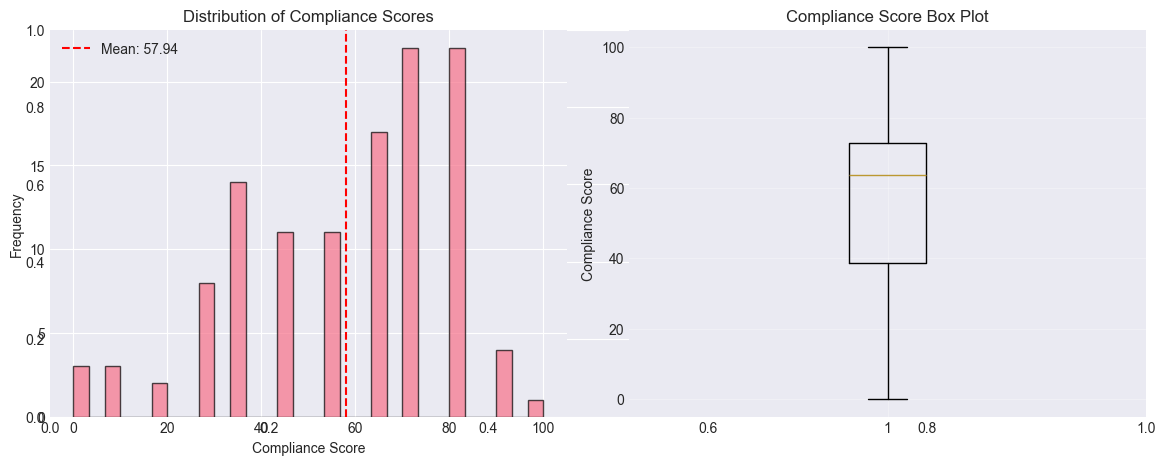

In [64]:
# Calculate compliance score
compliance_columns = [col for col in compliance_columns_mapping.values()]
df_processed['compliance_score'] = (
    df_processed[compliance_columns].sum(axis=1) / len(compliance_columns)
) * 100

print("=" * 80)
print("COMPLIANCE SCORE STATISTICS")
print("=" * 80)
print(df_processed['compliance_score'].describe())

# Visualize compliance score distribution
fig, ax = plt.subplots(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df_processed['compliance_score'], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Compliance Score')
plt.ylabel('Frequency')
plt.title('Distribution of Compliance Scores')
plt.axvline(df_processed['compliance_score'].mean(), color='red', 
            linestyle='--', label=f'Mean: {df_processed["compliance_score"].mean():.2f}')
plt.legend()

plt.subplot(1, 2, 2)
plt.boxplot(df_processed['compliance_score'], vert=True)
plt.ylabel('Compliance Score')
plt.title('Compliance Score Box Plot')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Risk Score Calculation

We'll calculate a comprehensive risk score based on:
- Antibiotic disposal practices
- Manure management methods
- Storage duration practices

In [65]:
# Define risk factors and their weights
risk_factors = {}

# Antibiotic disposal practices
disposal_columns = [
    'e_dispose_return', 'e_dispose_Incineration', 'e_dispose_as_waste',
    'e_dispose_field', 'p_dispose_Reuse', 'p_dispose_Incineration',
    'p_dispose_as_waste', 'p_dispose_field'
]

print("🔄 Processing disposal practices...")
for col in disposal_columns:
    if col in df_processed.columns:
        # Higher risk for improper disposal methods
        if col in ['e_dispose_as_waste', 'e_dispose_field', 'p_dispose_Reuse', 'p_dispose_field']:
            risk_factors[col] = 2  # Higher risk weight
            print(f"  ⚠️  {col} - HIGH RISK (weight: 2)")
        else:
            risk_factors[col] = 1  # Lower risk weight
            print(f"  ✓ {col} - LOW RISK (weight: 1)")
    else:
        df_processed[col] = 0
        risk_factors[col] = 1
        print(f"  ➖ {col} - not found, set to 0")

🔄 Processing disposal practices...
  ✓ e_dispose_return - LOW RISK (weight: 1)
  ✓ e_dispose_Incineration - LOW RISK (weight: 1)
  ⚠️  e_dispose_as_waste - HIGH RISK (weight: 2)
  ⚠️  e_dispose_field - HIGH RISK (weight: 2)
  ⚠️  p_dispose_Reuse - HIGH RISK (weight: 2)
  ✓ p_dispose_Incineration - LOW RISK (weight: 1)
  ✓ p_dispose_as_waste - LOW RISK (weight: 1)
  ⚠️  p_dispose_field - HIGH RISK (weight: 2)


In [66]:
# Manure management practices
manure_columns = [
    'manure_mngt_composting', 'manure_mngt_fields', 'manure_mngt_Storing',
    'manure_mngt_landfill', 'manure_mngt_Other'
]

print("\n🔄 Processing manure management practices...")
for col in manure_columns:
    if col in df_processed.columns:
        # Higher risk for improper manure management
        if col in ['manure_mngt_fields', 'manure_mngt_landfill']:
            risk_factors[col] = 2
            print(f"  ⚠️  {col} - HIGH RISK (weight: 2)")
        else:
            risk_factors[col] = 1
            print(f"  ✓ {col} - LOW RISK (weight: 1)")
    else:
        df_processed[col] = 0
        risk_factors[col] = 1
        print(f"  ➖ {col} - not found, set to 0")


🔄 Processing manure management practices...
  ✓ manure_mngt_composting - LOW RISK (weight: 1)
  ⚠️  manure_mngt_fields - HIGH RISK (weight: 2)
  ✓ manure_mngt_Storing - LOW RISK (weight: 1)
  ⚠️  manure_mngt_landfill - HIGH RISK (weight: 2)
  ✓ manure_mngt_Other - LOW RISK (weight: 1)


In [67]:
# Storage duration risk
storage_columns = [
    'store_lessweek', 'store_1-2 weeks', 'store_morethan2', 'store_dont_store'
]

print("\n🔄 Processing storage duration practices...")
for col in storage_columns:
    if col in df_processed.columns:
        if col in ['store_lessweek', 'store_dont_store']:
            risk_factors[col] = 2
            print(f"  ⚠️  {col} - HIGH RISK (weight: 2)")
        else:
            risk_factors[col] = 1
            print(f"  ✓ {col} - LOW RISK (weight: 1)")
    else:
        df_processed[col] = 0
        risk_factors[col] = 1
        print(f"  ➖ {col} - not found, set to 0")


🔄 Processing storage duration practices...
  ⚠️  store_lessweek - HIGH RISK (weight: 2)
  ✓ store_1-2 weeks - LOW RISK (weight: 1)
  ✓ store_morethan2 - LOW RISK (weight: 1)
  ⚠️  store_dont_store - HIGH RISK (weight: 2)


In [68]:
# Calculate weighted risk score
print("\n🔄 Calculating risk scores...")

risk_columns = list(risk_factors.keys())
max_possible_risk = sum(risk_factors.values())

# Calculate actual risk for each farm
df_processed['risk_score'] = 0
for col in risk_columns:
    df_processed['risk_score'] += df_processed[col] * risk_factors[col]

# Normalize to 0-100 scale
df_processed['risk_score'] = (df_processed['risk_score'] / max_possible_risk) * 100

print("=" * 80)
print("RISK SCORE STATISTICS")
print("=" * 80)
print(df_processed['risk_score'].describe())
print(f"\n📊 Maximum Possible Risk: {max_possible_risk}")
print(f"📊 Number of Risk Factors: {len(risk_factors)}")


🔄 Calculating risk scores...
RISK SCORE STATISTICS
count   118.000
mean     23.017
std       6.030
min      12.000
25%      20.000
50%      20.000
75%      28.000
max      40.000
Name: risk_score, dtype: float64

📊 Maximum Possible Risk: 25
📊 Number of Risk Factors: 17


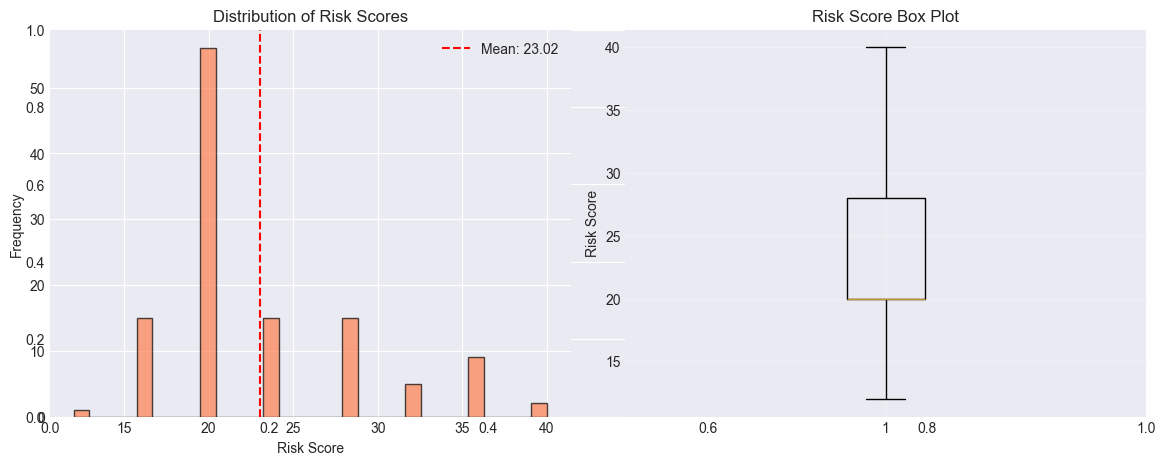

In [69]:
# Visualize risk score distribution
fig, ax = plt.subplots(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df_processed['risk_score'], bins=30, edgecolor='black', alpha=0.7, color='coral')
plt.xlabel('Risk Score')
plt.ylabel('Frequency')
plt.title('Distribution of Risk Scores')
plt.axvline(df_processed['risk_score'].mean(), color='red', 
            linestyle='--', label=f'Mean: {df_processed["risk_score"].mean():.2f}')
plt.legend()

plt.subplot(1, 2, 2)
plt.boxplot(df_processed['risk_score'], vert=True)
plt.ylabel('Risk Score')
plt.title('Risk Score Box Plot')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [70]:
# Identify high-risk and non-compliant farms
risk_threshold = df_processed['risk_score'].quantile(0.75)
df_processed['high_risk'] = df_processed['risk_score'].apply(lambda x: 1 if x >= risk_threshold else 0)

compliance_threshold = df_processed['compliance_score'].quantile(0.25)
df_processed['non_compliant'] = df_processed['compliance_score'].apply(
    lambda x: 1 if x <= compliance_threshold else 0
)

print("=" * 80)
print("CLASSIFICATION THRESHOLDS")
print("=" * 80)
print(f"Risk Threshold (75th percentile): {risk_threshold:.2f}")
print(f"Compliance Threshold (25th percentile): {compliance_threshold:.2f}")
print(f"\n📊 High Risk Farms: {df_processed['high_risk'].sum()} ({df_processed['high_risk'].sum()/len(df_processed)*100:.1f}%)")
print(f"📊 Non-Compliant Farms: {df_processed['non_compliant'].sum()} ({df_processed['non_compliant'].sum()/len(df_processed)*100:.1f}%)")

CLASSIFICATION THRESHOLDS
Risk Threshold (75th percentile): 28.00
Compliance Threshold (25th percentile): 38.64

📊 High Risk Farms: 31 (26.3%)
📊 Non-Compliant Farms: 30 (25.4%)


## 5. Vaccination and Disease Analysis

Processing vaccination data for chickens and pigs, along with antibiotic usage patterns.

In [71]:
# Process vaccination data
chicken_disease_columns = [col for col in df_processed.columns if 'disease_chicken' in col]
pig_disease_columns = [col for col in df_processed.columns if 'disease_pig' in col]

print("🔄 Processing disease data...")

if chicken_disease_columns:
    df_processed['chicken_disease_count'] = df_processed[chicken_disease_columns].sum(axis=1)
    print(f"  ✓ Chicken disease columns found: {len(chicken_disease_columns)}")
    print(f"    Columns: {', '.join(chicken_disease_columns[:5])}...")
else:
    df_processed['chicken_disease_count'] = 0
    print(f"  ⚠️  No chicken disease columns found")

if pig_disease_columns:
    df_processed['pig_disease_count'] = df_processed[pig_disease_columns].sum(axis=1)
    print(f"  ✓ Pig disease columns found: {len(pig_disease_columns)}")
    print(f"    Columns: {', '.join(pig_disease_columns[:5])}...")
else:
    df_processed['pig_disease_count'] = 0
    print(f"  ⚠️  No pig disease columns found")

🔄 Processing disease data...
  ✓ Chicken disease columns found: 7
    Columns: disease_chicken_Newcastle , disease_chicken_Infectious_Bursal , disease_chicken_Coccidiosis, disease_chicken_coryza, disease_chicken_Cholera...
  ✓ Pig disease columns found: 10
    Columns: disease_pig_Diarrhea, disease_pigs_African_swine, disease_pig_Swine_Erysipelas, disease_pig_Pneumonia, disease_pig_Swine_dysentery...


In [72]:
# Process antibiotic usage data
antibiotic_columns = [col for col in df_processed.columns if col.startswith('used_')]

print("\n🔄 Processing antibiotic usage data...")

if antibiotic_columns:
    df_processed['antibiotic_variety'] = df_processed[antibiotic_columns].sum(axis=1)
    print(f"  ✓ Antibiotic columns found: {len(antibiotic_columns)}")
    print(f"    Columns: {', '.join(antibiotic_columns[:5])}...")
else:
    df_processed['antibiotic_variety'] = 0
    print(f"  ⚠️  No antibiotic usage columns found")

print("\n=" * 80)
print("VACCINATION & ANTIBIOTIC STATISTICS")
print("=" * 80)
print(f"Chicken Diseases - Mean: {df_processed['chicken_disease_count'].mean():.2f}, Max: {df_processed['chicken_disease_count'].max()}")
print(f"Pig Diseases - Mean: {df_processed['pig_disease_count'].mean():.2f}, Max: {df_processed['pig_disease_count'].max()}")
print(f"Antibiotic Variety - Mean: {df_processed['antibiotic_variety'].mean():.2f}, Max: {df_processed['antibiotic_variety'].max()}")


🔄 Processing antibiotic usage data...
  ✓ Antibiotic columns found: 23
    Columns: used_Penicillin, used_Oxytetracycline, used_Trimethoprim_Sulfamethoxazole, used_Sulfadiazine, used_Enrofloxacin...

=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
VACCINATION & ANTIBIOTIC STATISTICS
Chicken Diseases - Mean: 1.78, Max: 6.0
Pig Diseases - Mean: 1.44, Max: 6.0
Antibiotic Variety - Mean: 3.47, Max: 12.0


In [73]:
# Handle missing values in key columns
required_columns = ['gender', 'age', 'education', 'farm_type', 'years_farming']

print("\n🔄 Handling missing values in key columns...")

for col in required_columns:
    if col not in df_processed.columns:
        print(f"  ❌ Required column '{col}' not found!")
    else:
        missing_count = df_processed[col].isnull().sum()
        if missing_count > 0:
            if col == 'years_farming':
                df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')
                median_val = df_processed[col].median()
                df_processed[col] = df_processed[col].fillna(median_val)
                print(f"  ✓ {col}: Filled {missing_count} missing values with median ({median_val:.2f})")
            else:
                mode_val = df_processed[col].mode()[0] if not df_processed[col].mode().empty else 'Unknown'
                df_processed[col] = df_processed[col].fillna(mode_val)
                print(f"  ✓ {col}: Filled {missing_count} missing values with mode ('{mode_val}')")
        else:
            print(f"  ✓ {col}: No missing values")

print("\n✅ Data preprocessing completed!")


🔄 Handling missing values in key columns...
  ✓ gender: No missing values
  ✓ age: No missing values
  ✓ education: No missing values
  ✓ farm_type: No missing values
  ✓ years_farming: Filled 1 missing values with median (3.00)

✅ Data preprocessing completed!


## 6. Exploratory Data Analysis (EDA)

### 6.1 Demographic Analysis

In [74]:
# Farm type distribution
if 'farm_type' in df_processed.columns:
    fig = px.pie(df_processed, names='farm_type', title='Farm Type Distribution',
                 hole=0.3, color_discrete_sequence=px.colors.qualitative.Set3)
    fig.update_traces(textposition='inside', textinfo='percent+label')
    fig.show()
    
    print("\nFarm Type Counts:")
    print(df_processed['farm_type'].value_counts())


Farm Type Counts:
farm_type
Poultry farm    54
Pig Farm        51
Both            13
Name: count, dtype: int64


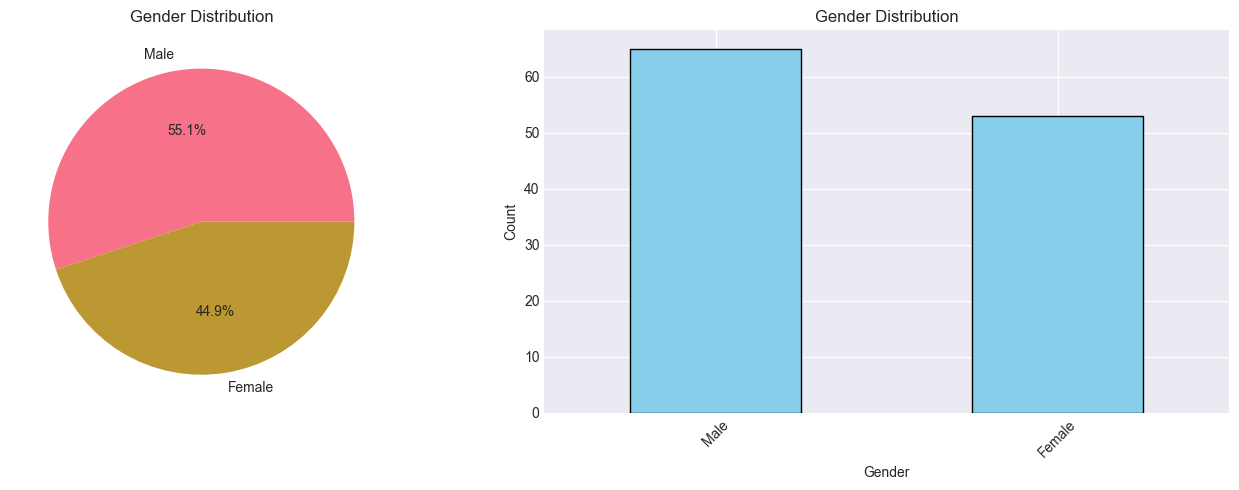


Gender Counts:
gender
Male      65
Female    53
Name: count, dtype: int64


In [75]:
# Gender distribution
if 'gender' in df_processed.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Pie chart
    df_processed['gender'].value_counts().plot(kind='pie', ax=axes[0], autopct='%1.1f%%')
    axes[0].set_title('Gender Distribution')
    axes[0].set_ylabel('')
    
    # Bar chart
    df_processed['gender'].value_counts().plot(kind='bar', ax=axes[1], color='skyblue', edgecolor='black')
    axes[1].set_title('Gender Distribution')
    axes[1].set_xlabel('Gender')
    axes[1].set_ylabel('Count')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    print("\nGender Counts:")
    print(df_processed['gender'].value_counts())

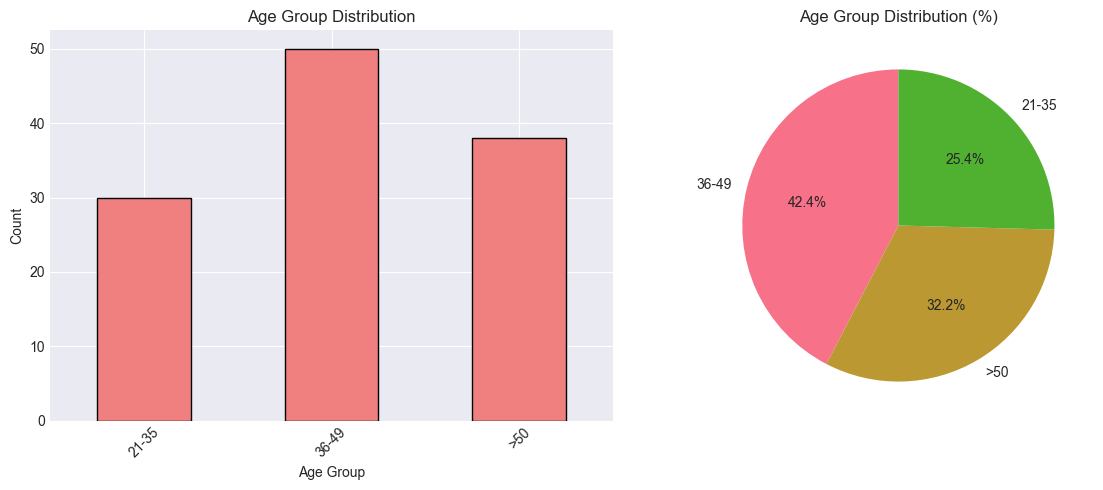


Age Group Counts:
age
21-35    30
36-49    50
>50      38
Name: count, dtype: int64


In [76]:
# Age distribution
if 'age' in df_processed.columns:
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    df_processed['age'].value_counts().sort_index().plot(kind='bar', color='lightcoral', edgecolor='black')
    plt.title('Age Group Distribution')
    plt.xlabel('Age Group')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    
    plt.subplot(1, 2, 2)
    age_counts = df_processed['age'].value_counts()
    plt.pie(age_counts, labels=age_counts.index, autopct='%1.1f%%', startangle=90)
    plt.title('Age Group Distribution (%)')
    
    plt.tight_layout()
    plt.show()
    
    print("\nAge Group Counts:")
    print(df_processed['age'].value_counts().sort_index())

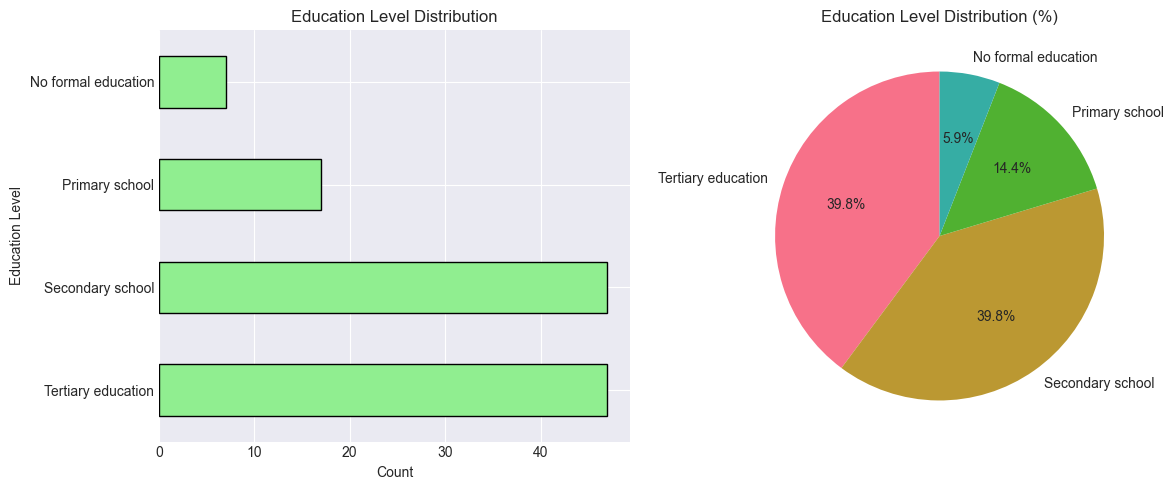


Education Level Counts:
education
Tertiary education     47
Secondary school       47
Primary school         17
No formal education     7
Name: count, dtype: int64


In [77]:
# Education level distribution
if 'education' in df_processed.columns:
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    df_processed['education'].value_counts().plot(kind='barh', color='lightgreen', edgecolor='black')
    plt.title('Education Level Distribution')
    plt.xlabel('Count')
    plt.ylabel('Education Level')
    
    plt.subplot(1, 2, 2)
    education_counts = df_processed['education'].value_counts()
    plt.pie(education_counts, labels=education_counts.index, autopct='%1.1f%%', startangle=90)
    plt.title('Education Level Distribution (%)')
    
    plt.tight_layout()
    plt.show()
    
    print("\nEducation Level Counts:")
    print(df_processed['education'].value_counts())

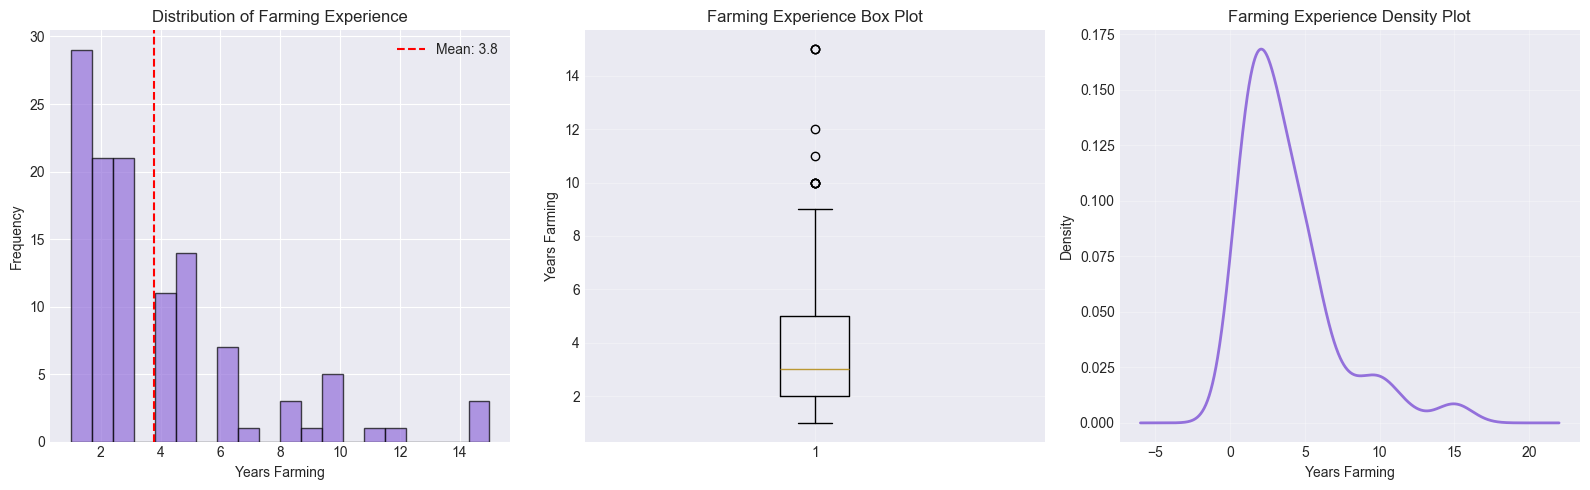


Farming Experience Statistics:
count   118.000
mean      3.797
std       3.123
min       1.000
25%       2.000
50%       3.000
75%       5.000
max      15.000
Name: years_farming, dtype: float64


In [78]:
# Years of farming experience
if 'years_farming' in df_processed.columns:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    # Histogram
    axes[0].hist(df_processed['years_farming'], bins=20, color='mediumpurple', edgecolor='black', alpha=0.7)
    axes[0].set_title('Distribution of Farming Experience')
    axes[0].set_xlabel('Years Farming')
    axes[0].set_ylabel('Frequency')
    axes[0].axvline(df_processed['years_farming'].mean(), color='red', linestyle='--', 
                    label=f'Mean: {df_processed["years_farming"].mean():.1f}')
    axes[0].legend()
    
    # Box plot
    axes[1].boxplot(df_processed['years_farming'], vert=True)
    axes[1].set_title('Farming Experience Box Plot')
    axes[1].set_ylabel('Years Farming')
    axes[1].grid(True, alpha=0.3)
    
    # KDE plot
    df_processed['years_farming'].plot(kind='density', ax=axes[2], color='mediumpurple', linewidth=2)
    axes[2].set_title('Farming Experience Density Plot')
    axes[2].set_xlabel('Years Farming')
    axes[2].set_ylabel('Density')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\nFarming Experience Statistics:")
    print(df_processed['years_farming'].describe())

### 6.2 Compliance and Risk Analysis

In [79]:
# Compliance vs Risk scatter plot
fig = px.scatter(df_processed, x='compliance_score', y='risk_score', 
                 color='farm_type', size='years_farming',
                 title='Compliance Score vs Risk Score by Farm Type',
                 labels={'compliance_score': 'Compliance Score (%)', 
                         'risk_score': 'Risk Score (%)'},
                 hover_data=['years_farming', 'chicken_disease_count', 'pig_disease_count'])
fig.add_hline(y=risk_threshold, line_dash="dash", line_color="red", 
              annotation_text="High Risk Threshold")
fig.add_vline(x=compliance_threshold, line_dash="dash", line_color="orange", 
              annotation_text="Low Compliance Threshold")
fig.show()

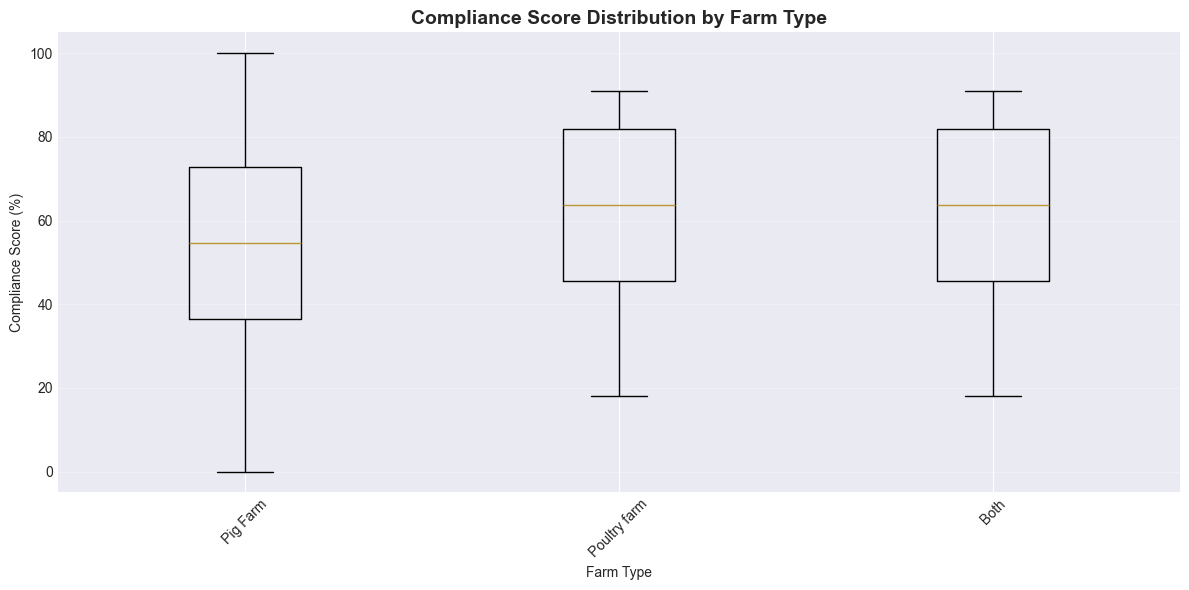


Compliance Score by Farm Type:
              count   mean    std    min    25%    50%    75%     max
farm_type                                                            
Both         13.000 58.741 23.063 18.182 45.455 63.636 81.818  90.909
Pig Farm     51.000 53.476 25.690  0.000 36.364 54.545 72.727 100.000
Poultry farm 54.000 61.953 18.944 18.182 45.455 63.636 81.818  90.909


In [80]:
# Compliance score by farm type
if 'farm_type' in df_processed.columns:
    plt.figure(figsize=(12, 6))
    
    farm_types = df_processed['farm_type'].unique()
    compliance_by_type = [df_processed[df_processed['farm_type']==ft]['compliance_score'].values 
                          for ft in farm_types]
    
    plt.boxplot(compliance_by_type, labels=farm_types)
    plt.title('Compliance Score Distribution by Farm Type', fontsize=14, fontweight='bold')
    plt.xlabel('Farm Type')
    plt.ylabel('Compliance Score (%)')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    print("\nCompliance Score by Farm Type:")
    print(df_processed.groupby('farm_type')['compliance_score'].describe())

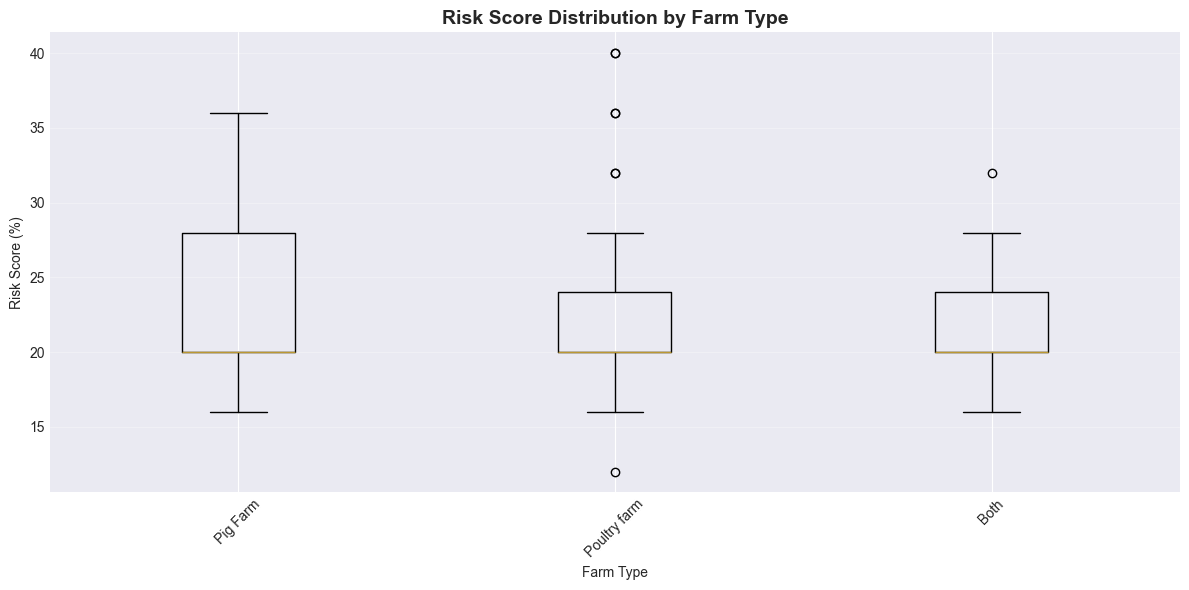


Risk Score by Farm Type:
              count   mean   std    min    25%    50%    75%    max
farm_type                                                          
Both         13.000 21.846 4.506 16.000 20.000 20.000 24.000 32.000
Pig Farm     51.000 24.078 6.222 16.000 20.000 20.000 28.000 36.000
Poultry farm 54.000 22.296 6.099 12.000 20.000 20.000 24.000 40.000


In [81]:
# Risk score by farm type
if 'farm_type' in df_processed.columns:
    plt.figure(figsize=(12, 6))
    
    farm_types = df_processed['farm_type'].unique()
    risk_by_type = [df_processed[df_processed['farm_type']==ft]['risk_score'].values 
                    for ft in farm_types]
    
    plt.boxplot(risk_by_type, labels=farm_types)
    plt.title('Risk Score Distribution by Farm Type', fontsize=14, fontweight='bold')
    plt.xlabel('Farm Type')
    plt.ylabel('Risk Score (%)')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    print("\nRisk Score by Farm Type:")
    print(df_processed.groupby('farm_type')['risk_score'].describe())

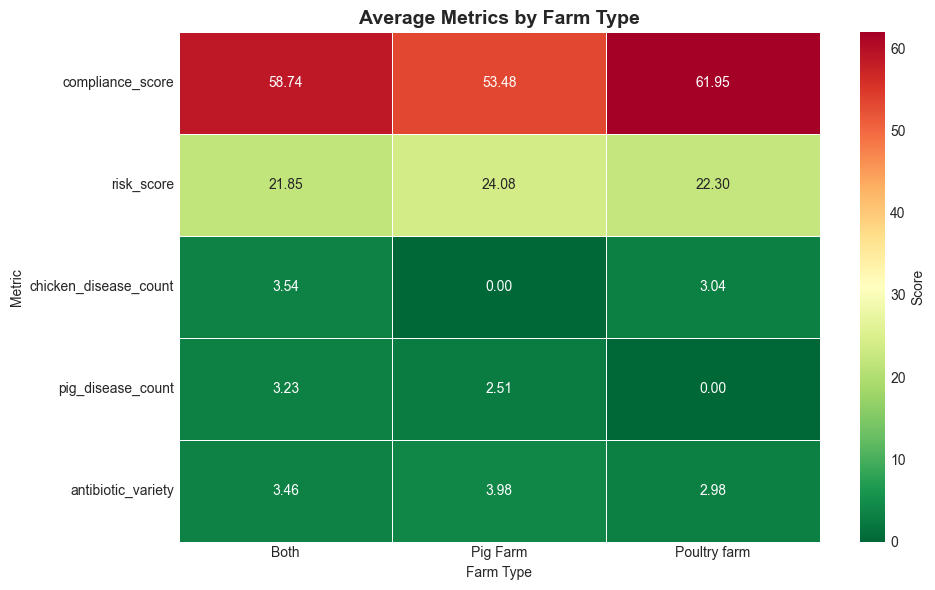

In [82]:
# Heatmap of compliance and risk by farm type
if 'farm_type' in df_processed.columns:
    pivot_data = df_processed.groupby('farm_type').agg({
        'compliance_score': 'mean',
        'risk_score': 'mean',
        'chicken_disease_count': 'mean',
        'pig_disease_count': 'mean',
        'antibiotic_variety': 'mean'
    }).round(2)
    
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot_data.T, annot=True, fmt='.2f', cmap='RdYlGn_r', 
                cbar_kws={'label': 'Score'}, linewidths=0.5)
    plt.title('Average Metrics by Farm Type', fontsize=14, fontweight='bold')
    plt.xlabel('Farm Type')
    plt.ylabel('Metric')
    plt.tight_layout()
    plt.show()

### 6.3 Disease and Antibiotic Analysis

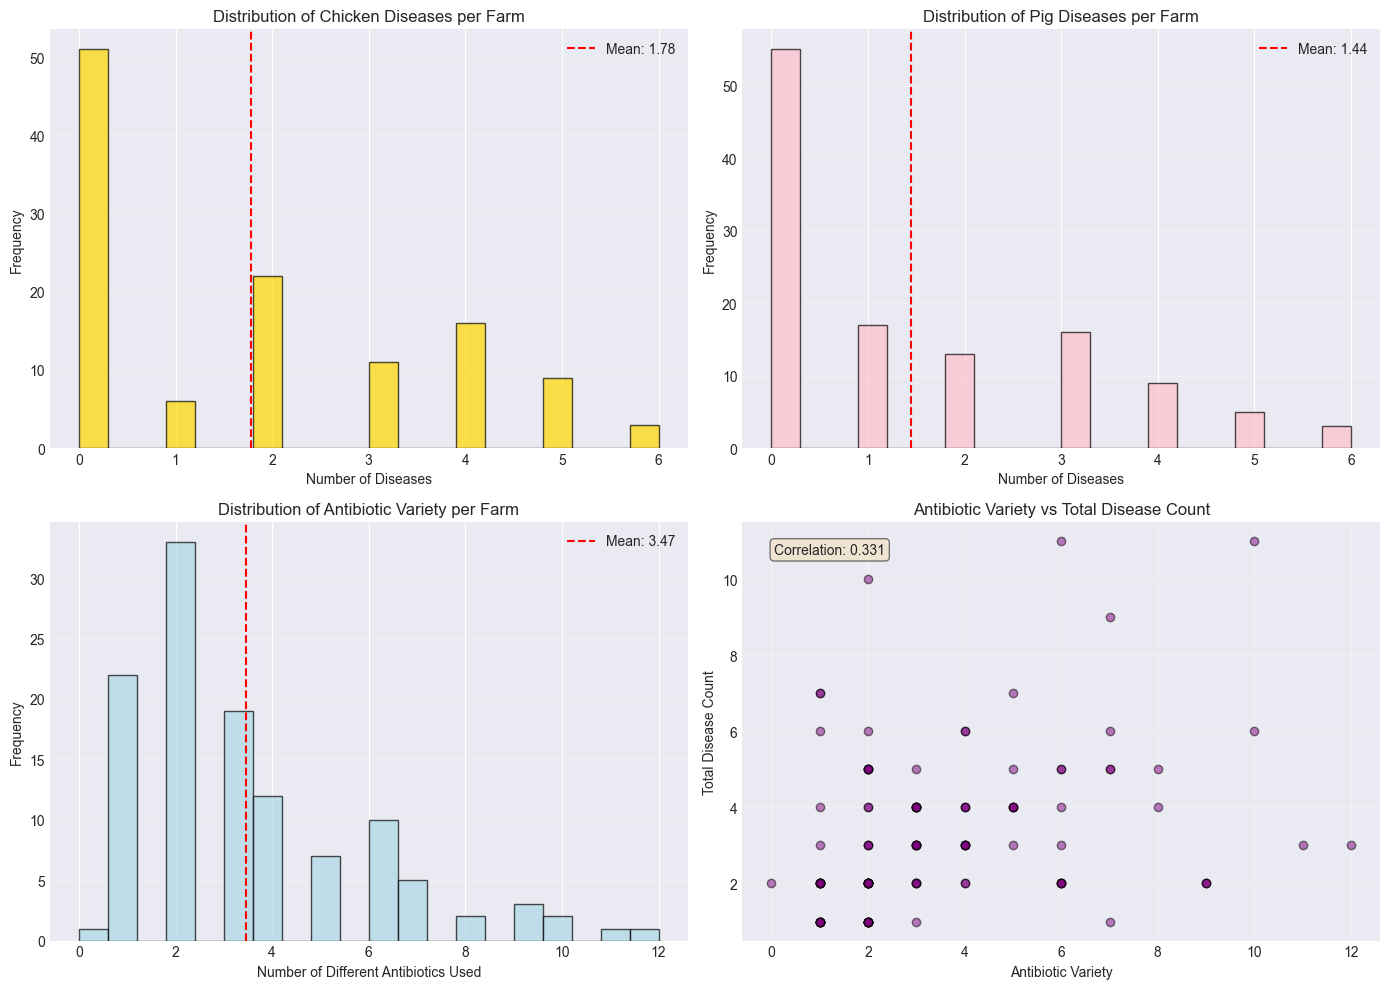

In [83]:
# Disease prevalence analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chicken disease distribution
axes[0, 0].hist(df_processed['chicken_disease_count'], bins=20, color='gold', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribution of Chicken Diseases per Farm')
axes[0, 0].set_xlabel('Number of Diseases')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(df_processed['chicken_disease_count'].mean(), color='red', 
                   linestyle='--', label=f'Mean: {df_processed["chicken_disease_count"].mean():.2f}')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Pig disease distribution
axes[0, 1].hist(df_processed['pig_disease_count'], bins=20, color='pink', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Distribution of Pig Diseases per Farm')
axes[0, 1].set_xlabel('Number of Diseases')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(df_processed['pig_disease_count'].mean(), color='red', 
                   linestyle='--', label=f'Mean: {df_processed["pig_disease_count"].mean():.2f}')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Antibiotic variety distribution
axes[1, 0].hist(df_processed['antibiotic_variety'], bins=20, color='lightblue', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Distribution of Antibiotic Variety per Farm')
axes[1, 0].set_xlabel('Number of Different Antibiotics Used')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].axvline(df_processed['antibiotic_variety'].mean(), color='red', 
                   linestyle='--', label=f'Mean: {df_processed["antibiotic_variety"].mean():.2f}')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Scatter: Antibiotic variety vs total disease count
df_processed['total_disease_count'] = df_processed['chicken_disease_count'] + df_processed['pig_disease_count']
axes[1, 1].scatter(df_processed['antibiotic_variety'], df_processed['total_disease_count'], 
                   alpha=0.5, c='purple', edgecolors='black')
axes[1, 1].set_title('Antibiotic Variety vs Total Disease Count')
axes[1, 1].set_xlabel('Antibiotic Variety')
axes[1, 1].set_ylabel('Total Disease Count')
axes[1, 1].grid(True, alpha=0.3)

# Add correlation coefficient
corr = df_processed[['antibiotic_variety', 'total_disease_count']].corr().iloc[0, 1]
axes[1, 1].text(0.05, 0.95, f'Correlation: {corr:.3f}', 
                transform=axes[1, 1].transAxes, fontsize=10, 
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

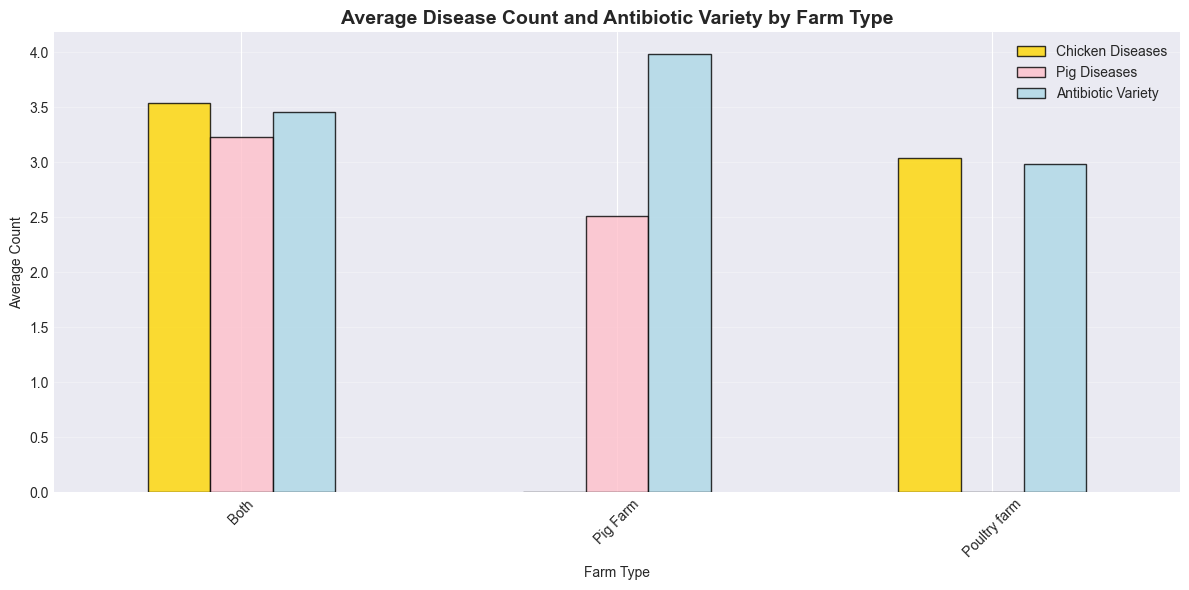


Disease and Antibiotic Statistics by Farm Type:
              chicken_disease_count  pig_disease_count  antibiotic_variety
farm_type                                                                 
Both                          3.540              3.230               3.460
Pig Farm                      0.000              2.510               3.980
Poultry farm                  3.040              0.000               2.980


In [84]:
# Disease count by farm type
if 'farm_type' in df_processed.columns:
    disease_by_farm = df_processed.groupby('farm_type').agg({
        'chicken_disease_count': 'mean',
        'pig_disease_count': 'mean',
        'antibiotic_variety': 'mean'
    }).round(2)
    
    disease_by_farm.plot(kind='bar', figsize=(12, 6), rot=45, 
                         color=['gold', 'pink', 'lightblue'], edgecolor='black', alpha=0.8)
    plt.title('Average Disease Count and Antibiotic Variety by Farm Type', 
              fontsize=14, fontweight='bold')
    plt.xlabel('Farm Type')
    plt.ylabel('Average Count')
    plt.legend(['Chicken Diseases', 'Pig Diseases', 'Antibiotic Variety'])
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
    
    print("\nDisease and Antibiotic Statistics by Farm Type:")
    print(disease_by_farm)

### 6.4 Correlation Analysis

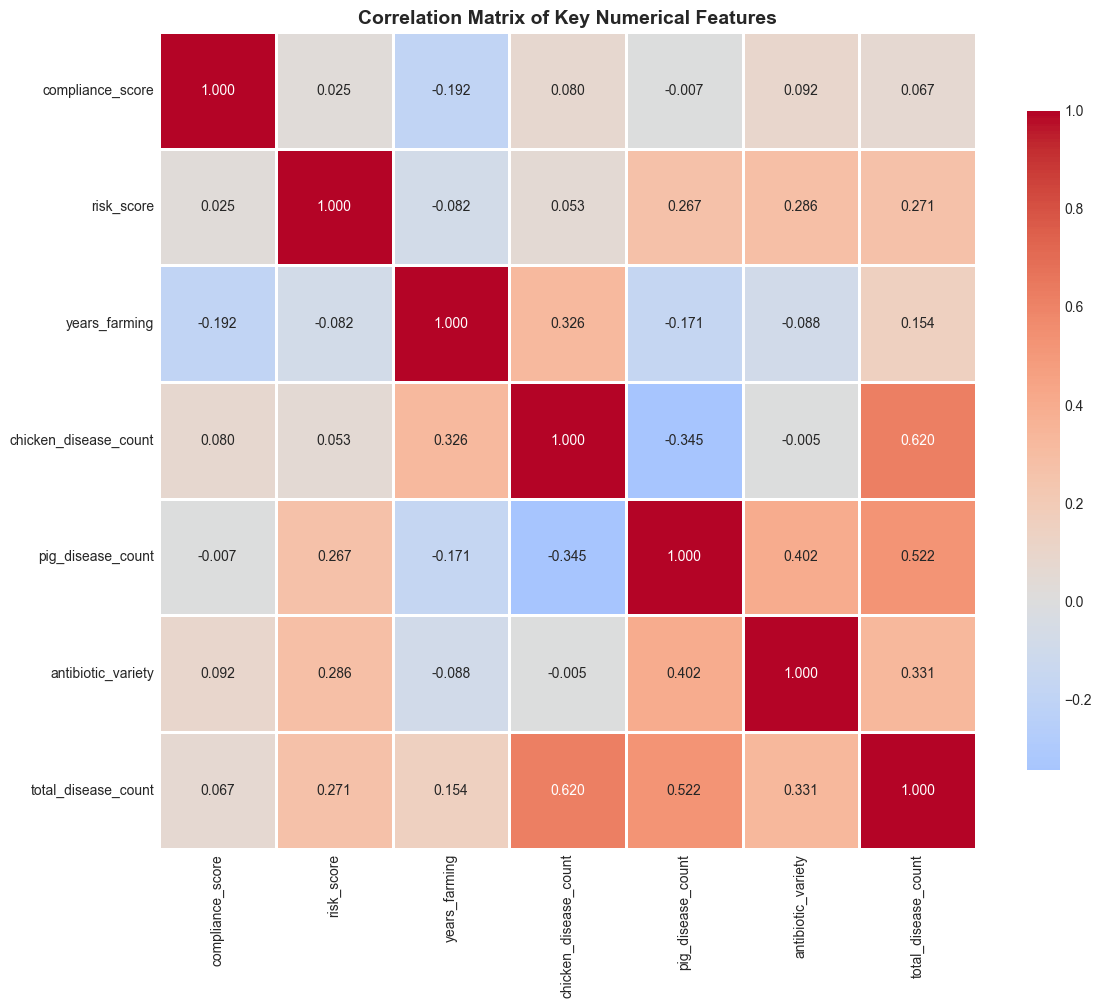


Top Positive Correlations:
chicken_disease_count  total_disease_count     0.620
total_disease_count    chicken_disease_count   0.620
pig_disease_count      total_disease_count     0.522
total_disease_count    pig_disease_count       0.522
antibiotic_variety     pig_disease_count       0.402
pig_disease_count      antibiotic_variety      0.402
total_disease_count    antibiotic_variety      0.331
antibiotic_variety     total_disease_count     0.331
years_farming          chicken_disease_count   0.326
chicken_disease_count  years_farming           0.326
dtype: float64

Top Negative Correlations:
pig_disease_count      chicken_disease_count   -0.345
chicken_disease_count  pig_disease_count       -0.345
compliance_score       years_farming           -0.192
years_farming          compliance_score        -0.192
                       pig_disease_count       -0.171
pig_disease_count      years_farming           -0.171
antibiotic_variety     years_farming           -0.088
years_farming        

In [85]:
# Correlation matrix of key numerical features
numerical_features = ['compliance_score', 'risk_score', 'years_farming', 
                      'chicken_disease_count', 'pig_disease_count', 
                      'antibiotic_variety', 'total_disease_count']

correlation_matrix = df_processed[numerical_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Key Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTop Positive Correlations:")
corr_pairs = correlation_matrix.unstack()
corr_pairs = corr_pairs[corr_pairs < 1.0]
print(corr_pairs.sort_values(ascending=False).head(10))

print("\nTop Negative Correlations:")
print(corr_pairs.sort_values(ascending=True).head(10))

## 7. Machine Learning Models

### 7.1 AMU Compliance Prediction Model

TRAINING AMU COMPLIANCE MODEL

📊 Features used: 8
  1. gender
  2. age
  3. education
  4. farm_type
  5. years_farming
  6. chicken_disease_count
  7. pig_disease_count
  8. antibiotic_variety

📊 Target distribution:
  Non-compliant: 30 (25.4%)
  Compliant: 88 (74.6%)

  ✓ Encoded 'gender': 2 unique values

  ✓ Encoded 'age': 3 unique values

  ✓ Encoded 'education': 4 unique values

  ✓ Encoded 'farm_type': 3 unique values

📊 Training set: 94 samples
📊 Testing set: 24 samples

🔄 Training Random Forest Classifier...
✅ Model trained successfully!

MODEL PERFORMANCE METRICS
Accuracy:  0.7083
Precision: 0.4286
Recall:    0.5000
F1-Score:  0.4615

CLASSIFICATION REPORT
               precision    recall  f1-score   support

    Compliant       0.82      0.78      0.80        18
Non-Compliant       0.43      0.50      0.46         6

     accuracy                           0.71        24
    macro avg       0.63      0.64      0.63        24
 weighted avg       0.72      0.71      0.72    

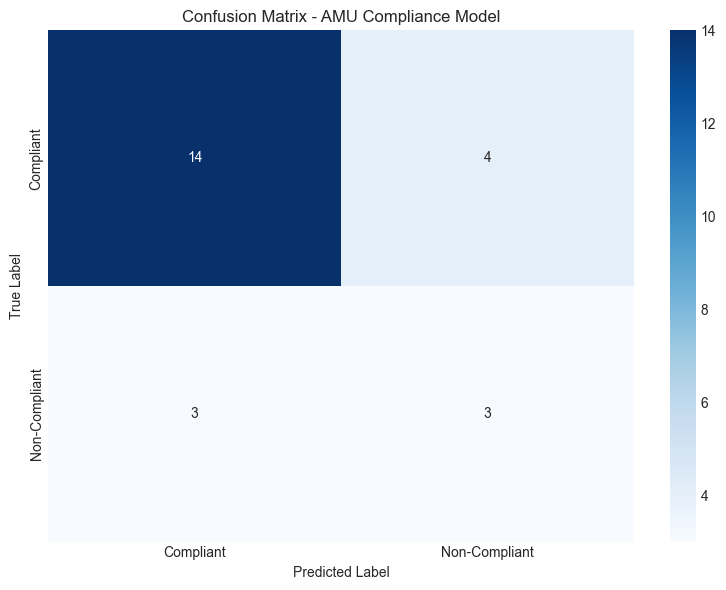

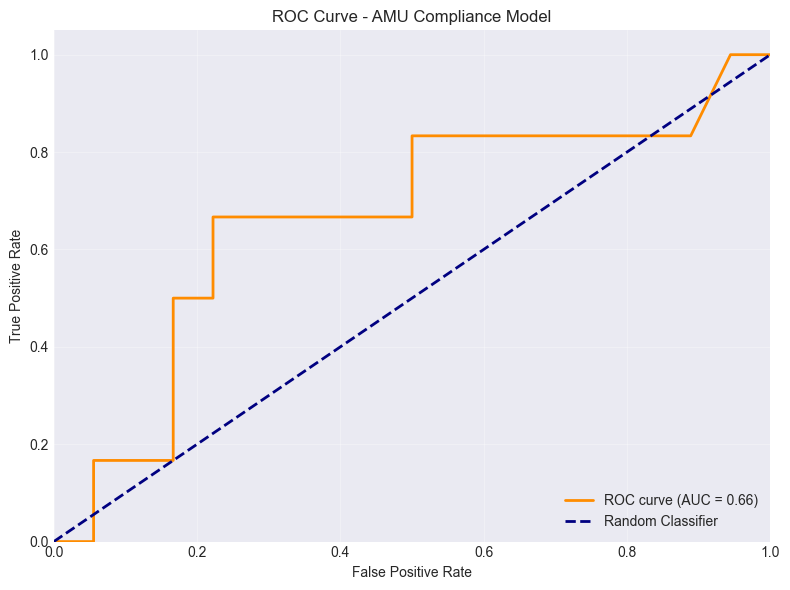

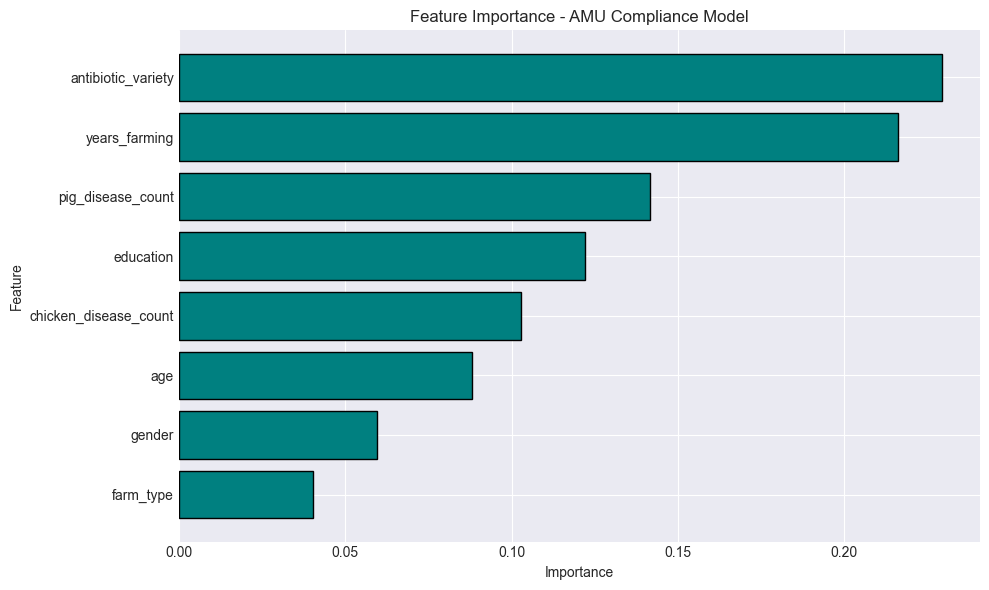


Feature Importance:
              feature  importance
   antibiotic_variety       0.229
        years_farming       0.216
    pig_disease_count       0.142
            education       0.122
chicken_disease_count       0.103
                  age       0.088
               gender       0.060
            farm_type       0.040


In [86]:
def train_amu_model(df):
    """
    Train a Random Forest Classifier to predict non-compliant farms
    """
    print("=" * 80)
    print("TRAINING AMU COMPLIANCE MODEL")
    print("=" * 80)
    
    # Define features
    feature_columns = [
        'gender', 'age', 'education', 'farm_type', 'years_farming',
        'chicken_disease_count', 'pig_disease_count', 'antibiotic_variety'
    ]
    
    # Filter to only include columns that exist
    feature_columns = [col for col in feature_columns if col in df.columns]
    print(f"\n📊 Features used: {len(feature_columns)}")
    for i, col in enumerate(feature_columns, 1):
        print(f"  {i}. {col}")
    
    X = df[feature_columns].copy()
    y = df['non_compliant']
    
    print(f"\n📊 Target distribution:")
    print(f"  Non-compliant: {y.sum()} ({y.sum()/len(y)*100:.1f}%)")
    print(f"  Compliant: {len(y)-y.sum()} ({(len(y)-y.sum())/len(y)*100:.1f}%)")
    
    # Encode categorical variables
    label_encoders = {}
    for col in X.columns:
        if X[col].dtype == 'object':
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))
            label_encoders[col] = le
            print(f"\n  ✓ Encoded '{col}': {len(le.classes_)} unique values")
    
    # Handle missing values
    X = X.fillna(0)
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print(f"\n📊 Training set: {len(X_train)} samples")
    print(f"📊 Testing set: {len(X_test)} samples")
    
    # Train model
    print("\n🔄 Training Random Forest Classifier...")
    model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
    model.fit(X_train, y_train)
    print("✅ Model trained successfully!")
    
    # Evaluate model
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print("\n" + "=" * 80)
    print("MODEL PERFORMANCE METRICS")
    print("=" * 80)
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    
    # Classification report
    print("\n" + "=" * 80)
    print("CLASSIFICATION REPORT")
    print("=" * 80)
    print(classification_report(y_test, y_pred, target_names=['Compliant', 'Non-Compliant']))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Compliant', 'Non-Compliant'],
                yticklabels=['Compliant', 'Non-Compliant'])
    plt.title('Confusion Matrix - AMU Compliance Model')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()
    
    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - AMU Compliance Model')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Feature importance
    feature_importance = pd.DataFrame({
        'feature': feature_columns,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance['feature'], feature_importance['importance'], color='teal', edgecolor='black')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.title('Feature Importance - AMU Compliance Model')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    print("\nFeature Importance:")
    print(feature_importance.to_string(index=False))
    
    return model, feature_columns, accuracy, label_encoders

# Train the model
amu_model, amu_features, amu_accuracy, amu_encoders = train_amu_model(df_processed)

### 7.2 Biosecurity Risk Prediction Model

TRAINING BIOSECURITY RISK MODEL

📊 Features used: 16
  1. gender
  2. age
  3. education
  4. farm_type
  5. years_farming
  6. chicken_disease_count
  7. pig_disease_count
  8. antibiotic_variety
  9. manure_mngt_composting
  10. manure_mngt_fields
  11. manure_mngt_Storing
  12. manure_mngt_landfill
  13. store_lessweek
  14. store_1-2 weeks
  15. store_morethan2
  16. store_dont_store

📊 Target distribution:
  High Risk: 31 (26.3%)
  Low Risk: 87 (73.7%)

  ✓ Encoded 'gender': 2 unique values

  ✓ Encoded 'age': 3 unique values

  ✓ Encoded 'education': 4 unique values

  ✓ Encoded 'farm_type': 3 unique values

📊 Training set: 94 samples
📊 Testing set: 24 samples

🔄 Training Random Forest Classifier...
✅ Model trained successfully!

MODEL PERFORMANCE METRICS
Accuracy:  0.8750
Precision: 0.7143
Recall:    0.8333
F1-Score:  0.7692

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Low Risk       0.94      0.89      0.91        18
   High Risk       0.71 

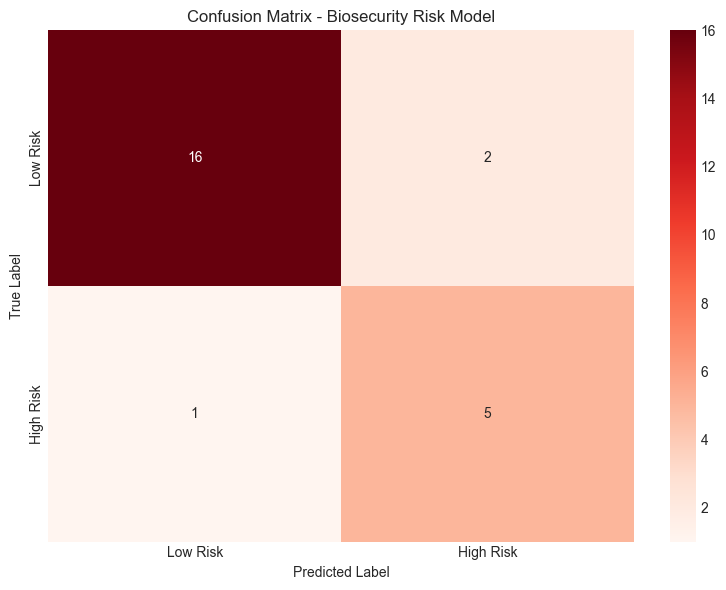

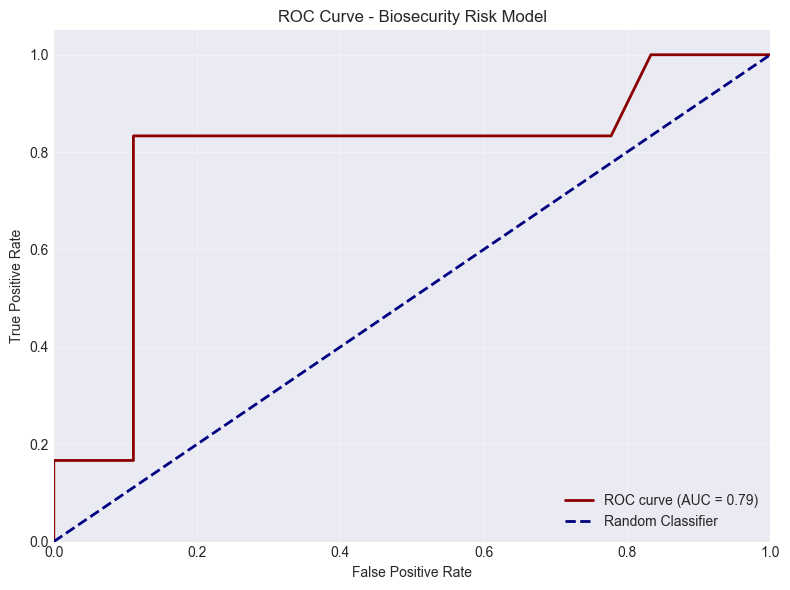

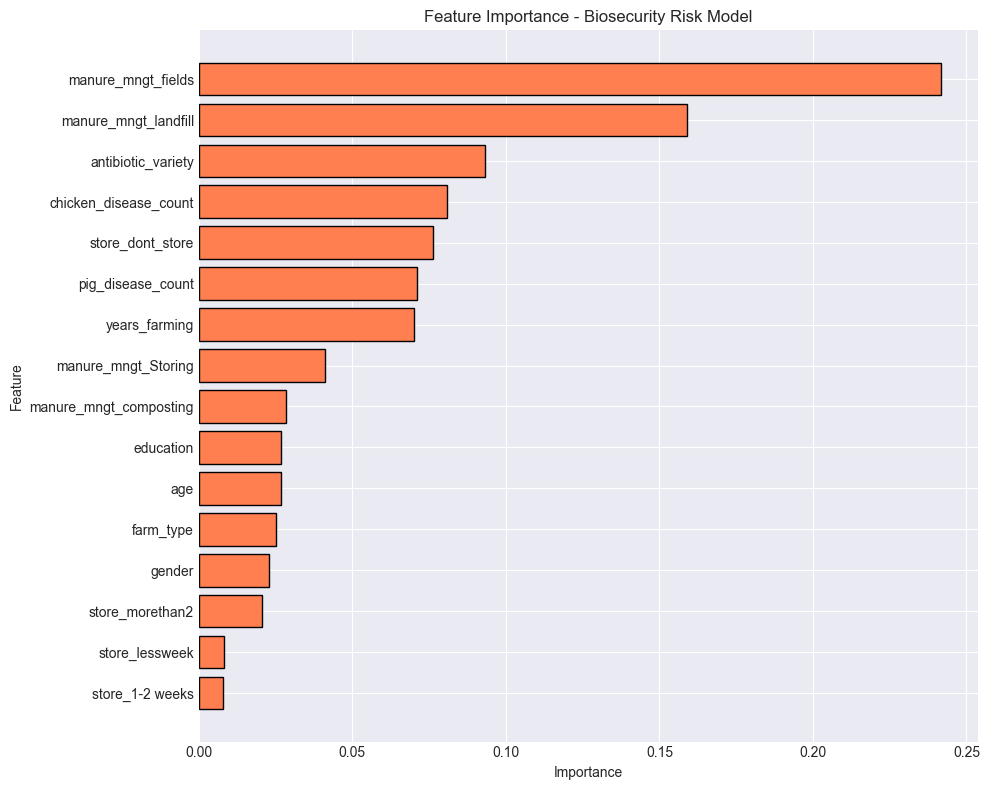


Feature Importance:
               feature  importance
    manure_mngt_fields       0.242
  manure_mngt_landfill       0.159
    antibiotic_variety       0.093
 chicken_disease_count       0.081
      store_dont_store       0.076
     pig_disease_count       0.071
         years_farming       0.070
   manure_mngt_Storing       0.041
manure_mngt_composting       0.029
             education       0.027
                   age       0.027
             farm_type       0.025
                gender       0.023
       store_morethan2       0.020
        store_lessweek       0.008
       store_1-2 weeks       0.008


In [87]:
def train_biosecurity_model(df):
    """
    Train a Random Forest Classifier to predict high-risk farms
    """
    print("=" * 80)
    print("TRAINING BIOSECURITY RISK MODEL")
    print("=" * 80)
    
    # Define features
    feature_columns = [
        'gender', 'age', 'education', 'farm_type', 'years_farming',
        'chicken_disease_count', 'pig_disease_count', 'antibiotic_variety'
    ]
    
    # Add manure management columns if available
    manure_columns = [
        'manure_mngt_composting', 'manure_mngt_fields', 'manure_mngt_Storing',
        'manure_mngt_landfill', 'store_lessweek', 'store_1-2 weeks',
        'store_morethan2', 'store_dont_store'
    ]
    
    for col in manure_columns:
        if col in df.columns:
            feature_columns.append(col)
    
    # Filter to only include columns that exist
    feature_columns = [col for col in feature_columns if col in df.columns]
    print(f"\n📊 Features used: {len(feature_columns)}")
    for i, col in enumerate(feature_columns, 1):
        print(f"  {i}. {col}")
    
    X = df[feature_columns].copy()
    y = df['high_risk']
    
    print(f"\n📊 Target distribution:")
    print(f"  High Risk: {y.sum()} ({y.sum()/len(y)*100:.1f}%)")
    print(f"  Low Risk: {len(y)-y.sum()} ({(len(y)-y.sum())/len(y)*100:.1f}%)")
    
    # Encode categorical variables
    label_encoders = {}
    for col in X.columns:
        if X[col].dtype == 'object':
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))
            label_encoders[col] = le
            print(f"\n  ✓ Encoded '{col}': {len(le.classes_)} unique values")
    
    # Handle missing values
    X = X.fillna(0)
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print(f"\n📊 Training set: {len(X_train)} samples")
    print(f"📊 Testing set: {len(X_test)} samples")
    
    # Train model
    print("\n🔄 Training Random Forest Classifier...")
    model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
    model.fit(X_train, y_train)
    print("✅ Model trained successfully!")
    
    # Evaluate model
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print("\n" + "=" * 80)
    print("MODEL PERFORMANCE METRICS")
    print("=" * 80)
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    
    # Classification report
    print("\n" + "=" * 80)
    print("CLASSIFICATION REPORT")
    print("=" * 80)
    print(classification_report(y_test, y_pred, target_names=['Low Risk', 'High Risk']))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
                xticklabels=['Low Risk', 'High Risk'],
                yticklabels=['Low Risk', 'High Risk'])
    plt.title('Confusion Matrix - Biosecurity Risk Model')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()
    
    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkred', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - Biosecurity Risk Model')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Feature importance
    feature_importance = pd.DataFrame({
        'feature': feature_columns,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    plt.figure(figsize=(10, 8))
    plt.barh(feature_importance['feature'], feature_importance['importance'], 
             color='coral', edgecolor='black')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.title('Feature Importance - Biosecurity Risk Model')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    print("\nFeature Importance:")
    print(feature_importance.to_string(index=False))
    
    return model, feature_columns, accuracy, label_encoders

# Train the model
bio_model, bio_features, bio_accuracy, bio_encoders = train_biosecurity_model(df_processed)

### 7.3 Cross-Validation Analysis

CROSS-VALIDATION: AMU COMPLIANCE MODEL

Cross-Validation Scores: [0.625      0.75       0.79166667 0.69565217 0.56521739]
Mean CV Accuracy: 0.6855 (+/- 0.1641)

CROSS-VALIDATION: BIOSECURITY RISK MODEL

Cross-Validation Scores: [0.91666667 0.875      0.91666667 0.95652174 0.82608696]
Mean CV Accuracy: 0.8982 (+/- 0.0886)


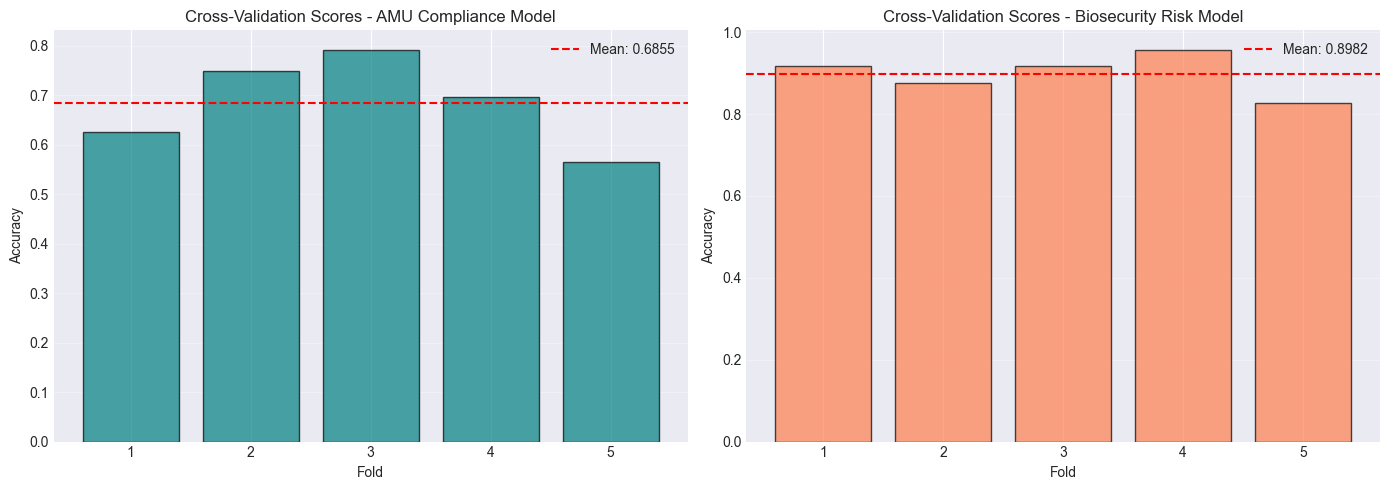

In [88]:
# Cross-validation for AMU model
print("=" * 80)
print("CROSS-VALIDATION: AMU COMPLIANCE MODEL")
print("=" * 80)

X_amu = df_processed[amu_features].copy()
y_amu = df_processed['non_compliant']

# Encode categorical variables
for col in X_amu.columns:
    if X_amu[col].dtype == 'object':
        le = LabelEncoder()
        X_amu[col] = le.fit_transform(X_amu[col].astype(str))

X_amu = X_amu.fillna(0)

cv_scores_amu = cross_val_score(amu_model, X_amu, y_amu, cv=5, scoring='accuracy')

print(f"\nCross-Validation Scores: {cv_scores_amu}")
print(f"Mean CV Accuracy: {cv_scores_amu.mean():.4f} (+/- {cv_scores_amu.std() * 2:.4f})")

# Cross-validation for Biosecurity model
print("\n" + "=" * 80)
print("CROSS-VALIDATION: BIOSECURITY RISK MODEL")
print("=" * 80)

X_bio = df_processed[bio_features].copy()
y_bio = df_processed['high_risk']

# Encode categorical variables
for col in X_bio.columns:
    if X_bio[col].dtype == 'object':
        le = LabelEncoder()
        X_bio[col] = le.fit_transform(X_bio[col].astype(str))

X_bio = X_bio.fillna(0)

cv_scores_bio = cross_val_score(bio_model, X_bio, y_bio, cv=5, scoring='accuracy')

print(f"\nCross-Validation Scores: {cv_scores_bio}")
print(f"Mean CV Accuracy: {cv_scores_bio.mean():.4f} (+/- {cv_scores_bio.std() * 2:.4f})")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, 6), cv_scores_amu, color='teal', edgecolor='black', alpha=0.7)
axes[0].axhline(y=cv_scores_amu.mean(), color='red', linestyle='--', 
                label=f'Mean: {cv_scores_amu.mean():.4f}')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Cross-Validation Scores - AMU Compliance Model')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(range(1, 6), cv_scores_bio, color='coral', edgecolor='black', alpha=0.7)
axes[1].axhline(y=cv_scores_bio.mean(), color='red', linestyle='--', 
                label=f'Mean: {cv_scores_bio.mean():.4f}')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Cross-Validation Scores - Biosecurity Risk Model')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 8. Anomaly Detection

Using Isolation Forest to detect anomalous farms based on multiple features.

In [89]:
def detect_anomalies(df):
    """
    Detect anomalous farms using Isolation Forest
    """
    print("=" * 80)
    print("ANOMALY DETECTION")
    print("=" * 80)
    
    numerical_features = [
        'compliance_score', 'risk_score', 'years_farming',
        'chicken_disease_count', 'pig_disease_count', 'antibiotic_variety'
    ]
    
    # Filter to only include columns that exist
    numerical_features = [col for col in numerical_features if col in df.columns]
    print(f"\n📊 Features used for anomaly detection: {len(numerical_features)}")
    for i, col in enumerate(numerical_features, 1):
        print(f"  {i}. {col}")
    
    # Prepare data
    X = df[numerical_features].copy()
    X = X.fillna(0)
    
    # Scale the data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    print("\n🔄 Training Isolation Forest...")
    # Detect anomalies using Isolation Forest
    iso_forest = IsolationForest(contamination=0.1, random_state=42, n_estimators=100)
    anomalies = iso_forest.fit_predict(X_scaled)
    
    df['anomaly'] = anomalies
    df['anomaly'] = df['anomaly'].apply(lambda x: 1 if x == -1 else 0)
    df['anomaly_score'] = iso_forest.score_samples(X_scaled)
    
    anomaly_count = df['anomaly'].sum()
    print(f"\n✅ Anomaly detection completed!")
    print(f"📊 Anomalies detected: {anomaly_count} ({anomaly_count/len(df)*100:.1f}%)")
    print(f"📊 Normal samples: {len(df)-anomaly_count} ({(len(df)-anomaly_count)/len(df)*100:.1f}%)")
    
    return df, scaler

# Detect anomalies
df_with_anomalies, anomaly_scaler = detect_anomalies(df_processed)

ANOMALY DETECTION

📊 Features used for anomaly detection: 6
  1. compliance_score
  2. risk_score
  3. years_farming
  4. chicken_disease_count
  5. pig_disease_count
  6. antibiotic_variety

🔄 Training Isolation Forest...

✅ Anomaly detection completed!
📊 Anomalies detected: 12 (10.2%)
📊 Normal samples: 106 (89.8%)


In [90]:
# Visualize anomalies
anomalies = df_with_anomalies[df_with_anomalies['anomaly'] == 1]

print("=" * 80)
print("ANOMALOUS FARMS DETAILS")
print("=" * 80)
print(f"\nTotal anomalous farms: {len(anomalies)}\n")

if len(anomalies) > 0:
    display_cols = ['farm_type', 'compliance_score', 'risk_score', 'years_farming',
                    'chicken_disease_count', 'pig_disease_count', 'antibiotic_variety', 
                    'anomaly_score']
    display_cols = [col for col in display_cols if col in anomalies.columns]
    print(anomalies[display_cols].head(10))

ANOMALOUS FARMS DETAILS

Total anomalous farms: 12

       farm_type  compliance_score  risk_score  years_farming  \
1       Pig Farm             0.000      24.000          6.000   
3       Pig Farm            27.273      20.000          5.000   
4       Pig Farm             0.000      24.000          2.000   
5       Pig Farm            90.909      20.000          4.000   
43      Pig Farm           100.000      36.000          3.000   
70          Both            81.818      24.000          2.000   
77  Poultry farm            90.909      16.000         12.000   
84          Both            81.818      20.000          4.000   
87          Both            90.909      16.000          3.000   
98          Both            72.727      32.000         10.000   

    chicken_disease_count  pig_disease_count  antibiotic_variety  \
1                   0.000              5.000               6.000   
3                   0.000              3.000              11.000   
4                   0.000   

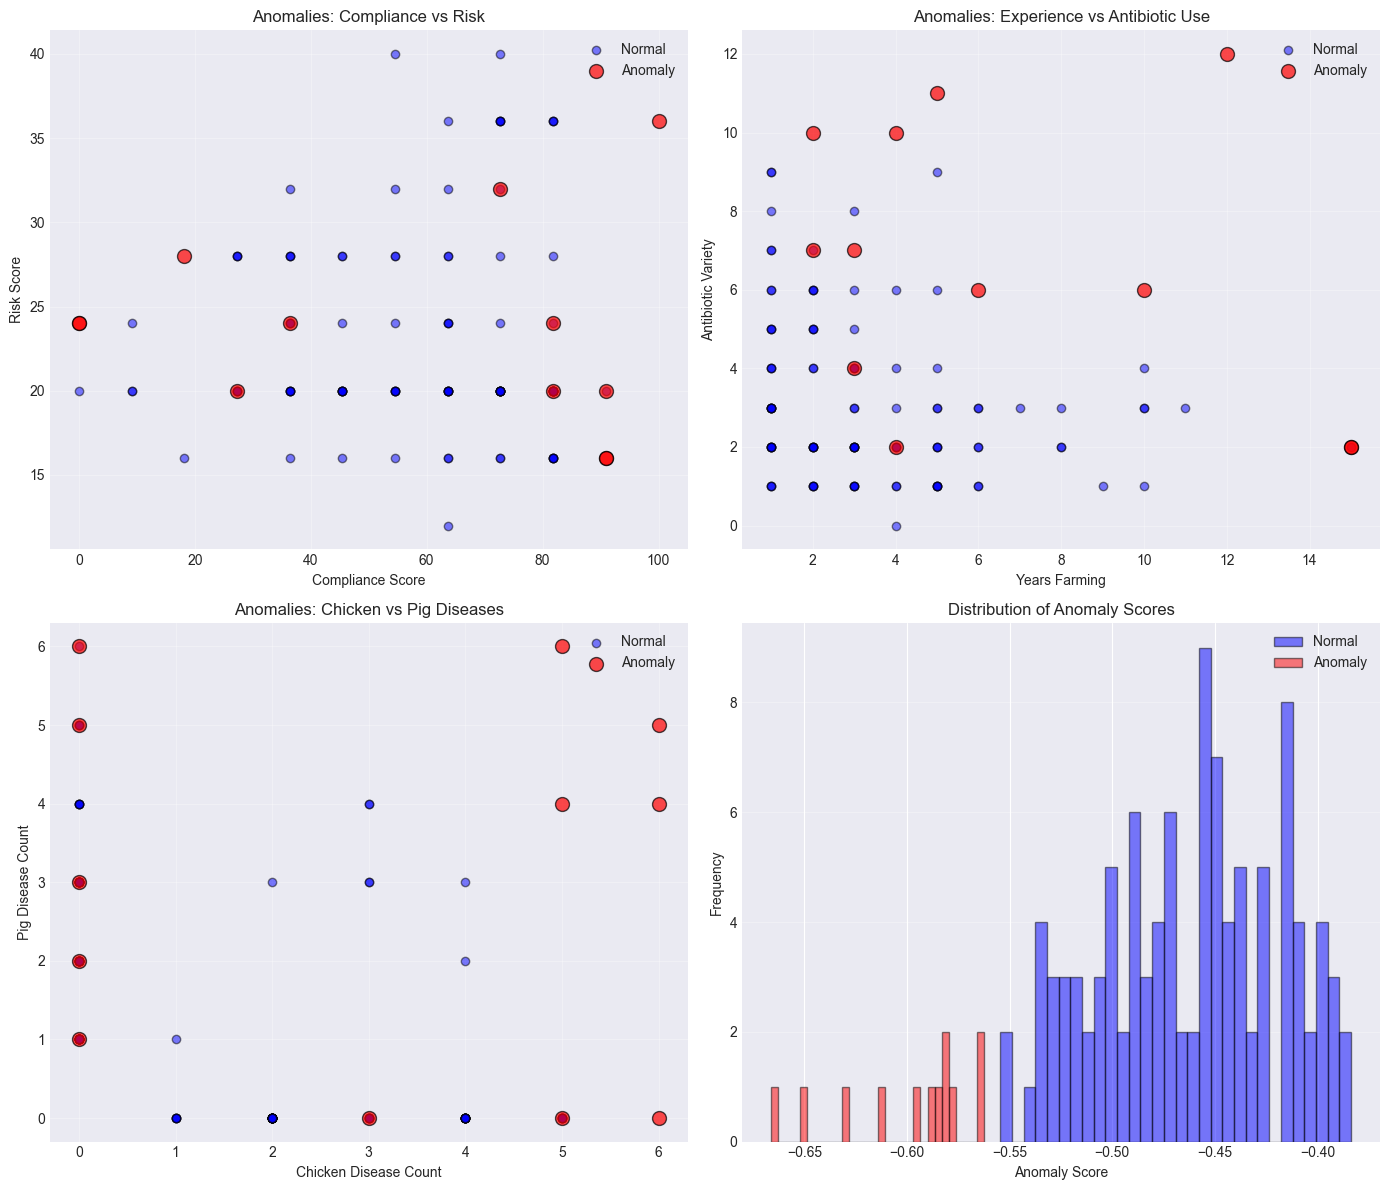

In [91]:
# 2D scatter plots of anomalies
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Compliance vs Risk
axes[0, 0].scatter(df_with_anomalies[df_with_anomalies['anomaly']==0]['compliance_score'],
                   df_with_anomalies[df_with_anomalies['anomaly']==0]['risk_score'],
                   c='blue', label='Normal', alpha=0.5, edgecolors='black')
axes[0, 0].scatter(df_with_anomalies[df_with_anomalies['anomaly']==1]['compliance_score'],
                   df_with_anomalies[df_with_anomalies['anomaly']==1]['risk_score'],
                   c='red', label='Anomaly', alpha=0.7, s=100, edgecolors='black')
axes[0, 0].set_xlabel('Compliance Score')
axes[0, 0].set_ylabel('Risk Score')
axes[0, 0].set_title('Anomalies: Compliance vs Risk')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Years farming vs Antibiotic variety
axes[0, 1].scatter(df_with_anomalies[df_with_anomalies['anomaly']==0]['years_farming'],
                   df_with_anomalies[df_with_anomalies['anomaly']==0]['antibiotic_variety'],
                   c='blue', label='Normal', alpha=0.5, edgecolors='black')
axes[0, 1].scatter(df_with_anomalies[df_with_anomalies['anomaly']==1]['years_farming'],
                   df_with_anomalies[df_with_anomalies['anomaly']==1]['antibiotic_variety'],
                   c='red', label='Anomaly', alpha=0.7, s=100, edgecolors='black')
axes[0, 1].set_xlabel('Years Farming')
axes[0, 1].set_ylabel('Antibiotic Variety')
axes[0, 1].set_title('Anomalies: Experience vs Antibiotic Use')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Chicken diseases vs Pig diseases
axes[1, 0].scatter(df_with_anomalies[df_with_anomalies['anomaly']==0]['chicken_disease_count'],
                   df_with_anomalies[df_with_anomalies['anomaly']==0]['pig_disease_count'],
                   c='blue', label='Normal', alpha=0.5, edgecolors='black')
axes[1, 0].scatter(df_with_anomalies[df_with_anomalies['anomaly']==1]['chicken_disease_count'],
                   df_with_anomalies[df_with_anomalies['anomaly']==1]['pig_disease_count'],
                   c='red', label='Anomaly', alpha=0.7, s=100, edgecolors='black')
axes[1, 0].set_xlabel('Chicken Disease Count')
axes[1, 0].set_ylabel('Pig Disease Count')
axes[1, 0].set_title('Anomalies: Chicken vs Pig Diseases')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Anomaly score distribution
axes[1, 1].hist(df_with_anomalies[df_with_anomalies['anomaly']==0]['anomaly_score'],
                bins=30, alpha=0.5, label='Normal', color='blue', edgecolor='black')
axes[1, 1].hist(df_with_anomalies[df_with_anomalies['anomaly']==1]['anomaly_score'],
                bins=30, alpha=0.5, label='Anomaly', color='red', edgecolor='black')
axes[1, 1].set_xlabel('Anomaly Score')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Anomaly Scores')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [92]:
# 3D visualization of anomalies using Plotly
fig = px.scatter_3d(df_with_anomalies, 
                    x='compliance_score', 
                    y='risk_score',
                    z='years_farming', 
                    color='anomaly',
                    color_discrete_map={0: 'blue', 1: 'red'},
                    labels={'anomaly': 'Type'},
                    title='3D Anomaly Detection Visualization',
                    hover_data=['farm_type', 'chicken_disease_count', 'pig_disease_count'])
fig.update_traces(marker=dict(size=5))
fig.show()

## 9. Model Persistence

Save all trained models and preprocessors for future use.

In [93]:
# Save all models and data
print("=" * 80)
print("SAVING MODELS AND DATA")
print("=" * 80)

# Create models dictionary
models_data = {
    'amu_model': amu_model,
    'amu_features': amu_features,
    'amu_accuracy': amu_accuracy,
    'amu_encoders': amu_encoders,
    'bio_model': bio_model,
    'bio_features': bio_features,
    'bio_accuracy': bio_accuracy,
    'bio_encoders': bio_encoders,
    'anomaly_scaler': anomaly_scaler,
    'risk_threshold': risk_threshold,
    'compliance_threshold': compliance_threshold
}

# Save to pickle file
with open('livestock_models.pkl', 'wb') as f:
    pickle.dump(models_data, f)
print("\n✅ Models saved to 'livestock_models.pkl'")

# Save individual models as well
with open('amu_model.pkl', 'wb') as f:
    pickle.dump({'model': amu_model, 'features': amu_features, 'accuracy': amu_accuracy}, f)
print("✅ AMU model saved to 'amu_model.pkl'")

with open('bio_model.pkl', 'wb') as f:
    pickle.dump({'model': bio_model, 'features': bio_features, 'accuracy': bio_accuracy}, f)
print("✅ Biosecurity model saved to 'bio_model.pkl'")

# Save processed data
df_with_anomalies.to_csv('processed_livestock_data.csv', index=False)
print("✅ Processed data saved to 'processed_livestock_data.csv'")

print("\n" + "=" * 80)
print("ALL MODELS AND DATA SAVED SUCCESSFULLY!")
print("=" * 80)

SAVING MODELS AND DATA

✅ Models saved to 'livestock_models.pkl'
✅ AMU model saved to 'amu_model.pkl'
✅ Biosecurity model saved to 'bio_model.pkl'
✅ Processed data saved to 'processed_livestock_data.csv'

ALL MODELS AND DATA SAVED SUCCESSFULLY!


## 10. Summary Report and Key Insights

In [94]:
print("=" * 80)
print("LIVESTOCK MONITORING & BIOSECURITY AI SYSTEM")
print("COMPREHENSIVE ANALYSIS SUMMARY REPORT")
print("=" * 80)

print(f"\n{'Dataset Overview':-^80}")
print(f"Total Farms Analyzed: {len(df_processed)}")
print(f"Number of Features: {df_processed.shape[1]}")
if 'farm_type' in df_processed.columns:
    print(f"Farm Types: {df_processed['farm_type'].nunique()}")

print(f"\n{'Compliance Analysis':-^80}")
print(f"Average Compliance Score: {df_processed['compliance_score'].mean():.2f}%")
print(f"Median Compliance Score: {df_processed['compliance_score'].median():.2f}%")
print(f"Non-Compliant Farms: {df_processed['non_compliant'].sum()} ({df_processed['non_compliant'].sum()/len(df_processed)*100:.1f}%)")
print(f"Compliance Threshold: {compliance_threshold:.2f}%")

print(f"\n{'Risk Assessment':-^80}")
print(f"Average Risk Score: {df_processed['risk_score'].mean():.2f}%")
print(f"Median Risk Score: {df_processed['risk_score'].median():.2f}%")
print(f"High Risk Farms: {df_processed['high_risk'].sum()} ({df_processed['high_risk'].sum()/len(df_processed)*100:.1f}%)")
print(f"Risk Threshold: {risk_threshold:.2f}%")

print(f"\n{'Disease & Antibiotic Analysis':-^80}")
print(f"Average Chicken Diseases per Farm: {df_processed['chicken_disease_count'].mean():.2f}")
print(f"Average Pig Diseases per Farm: {df_processed['pig_disease_count'].mean():.2f}")
print(f"Average Antibiotic Variety: {df_processed['antibiotic_variety'].mean():.2f}")
print(f"Total Disease Burden: {df_processed['total_disease_count'].sum():.0f}")

print(f"\n{'Machine Learning Models Performance':-^80}")
print(f"AMU Compliance Model Accuracy: {amu_accuracy*100:.2f}%")
print(f"Biosecurity Risk Model Accuracy: {bio_accuracy*100:.2f}%")
print(f"AMU Model Features: {len(amu_features)}")
print(f"Biosecurity Model Features: {len(bio_features)}")

print(f"\n{'Anomaly Detection':-^80}")
anomaly_count = df_with_anomalies['anomaly'].sum()
print(f"Anomalous Farms Detected: {anomaly_count} ({anomaly_count/len(df_with_anomalies)*100:.1f}%)")
print(f"Detection Method: Isolation Forest (contamination=0.1)")

if 'farm_type' in df_processed.columns:
    print(f"\n{'Farm Type Distribution':-^80}")
    for farm_type, count in df_processed['farm_type'].value_counts().items():
        percentage = (count / len(df_processed)) * 100
        print(f"{farm_type}: {count} ({percentage:.1f}%)")

print("\n" + "=" * 80)
print("END OF SUMMARY REPORT")
print("=" * 80)

LIVESTOCK MONITORING & BIOSECURITY AI SYSTEM
COMPREHENSIVE ANALYSIS SUMMARY REPORT

--------------------------------Dataset Overview--------------------------------
Total Farms Analyzed: 118
Number of Features: 166
Farm Types: 3

------------------------------Compliance Analysis-------------------------------
Average Compliance Score: 57.94%
Median Compliance Score: 63.64%
Non-Compliant Farms: 30 (25.4%)
Compliance Threshold: 38.64%

--------------------------------Risk Assessment---------------------------------
Average Risk Score: 23.02%
Median Risk Score: 20.00%
High Risk Farms: 31 (26.3%)
Risk Threshold: 28.00%

-------------------------Disease & Antibiotic Analysis--------------------------
Average Chicken Diseases per Farm: 1.78
Average Pig Diseases per Farm: 1.44
Average Antibiotic Variety: 3.47
Total Disease Burden: 380

----------------------Machine Learning Models Performance-----------------------
AMU Compliance Model Accuracy: 70.83%
Biosecurity Risk Model Accuracy: 87.50%


## 11. Key Recommendations Based on Analysis

In [95]:
print("=" * 80)
print("KEY RECOMMENDATIONS FOR LIVESTOCK MANAGEMENT")
print("=" * 80)

recommendations = []

# Compliance-based recommendations
low_compliance_pct = (df_processed['non_compliant'].sum() / len(df_processed)) * 100
if low_compliance_pct > 30:
    recommendations.append({
        'category': 'CRITICAL',
        'area': 'AMU Compliance',
        'finding': f'{low_compliance_pct:.1f}% of farms are non-compliant',
        'action': 'Implement mandatory training programs and regular compliance audits'
    })
elif low_compliance_pct > 15:
    recommendations.append({
        'category': 'HIGH PRIORITY',
        'area': 'AMU Compliance',
        'finding': f'{low_compliance_pct:.1f}% of farms are non-compliant',
        'action': 'Increase veterinary consultation requirements and monitoring'
    })

# Risk-based recommendations
high_risk_pct = (df_processed['high_risk'].sum() / len(df_processed)) * 100
if high_risk_pct > 30:
    recommendations.append({
        'category': 'CRITICAL',
        'area': 'Biosecurity Risk',
        'finding': f'{high_risk_pct:.1f}% of farms are high-risk',
        'action': 'Immediate biosecurity protocol enforcement and farm inspections'
    })
elif high_risk_pct > 15:
    recommendations.append({
        'category': 'HIGH PRIORITY',
        'area': 'Biosecurity Risk',
        'finding': f'{high_risk_pct:.1f}% of farms are high-risk',
        'action': 'Enhanced biosecurity training and waste management protocols'
    })

# Disease burden recommendations
avg_total_diseases = df_processed['total_disease_count'].mean()
if avg_total_diseases > 3:
    recommendations.append({
        'category': 'HIGH PRIORITY',
        'area': 'Disease Management',
        'finding': f'Average disease burden is {avg_total_diseases:.1f} per farm',
        'action': 'Strengthen vaccination programs and disease prevention measures'
    })

# Antibiotic usage recommendations
avg_antibiotics = df_processed['antibiotic_variety'].mean()
if avg_antibiotics > 5:
    recommendations.append({
        'category': 'MODERATE',
        'area': 'Antibiotic Stewardship',
        'finding': f'Average antibiotic variety usage is {avg_antibiotics:.1f}',
        'action': 'Review antibiotic prescribing practices and promote narrow-spectrum alternatives'
    })

# Anomaly recommendations
anomaly_pct = (df_with_anomalies['anomaly'].sum() / len(df_with_anomalies)) * 100
if anomaly_pct > 5:
    recommendations.append({
        'category': 'MODERATE',
        'area': 'Farm Monitoring',
        'finding': f'{anomaly_pct:.1f}% of farms show anomalous patterns',
        'action': 'Conduct targeted inspections of flagged farms for unusual practices'
    })

# Display recommendations
if recommendations:
    for i, rec in enumerate(recommendations, 1):
        print(f"\n{i}. [{rec['category']}] {rec['area']}")
        print(f"   Finding: {rec['finding']}")
        print(f"   Action: {rec['action']}")
else:
    print("\n✅ Overall performance is satisfactory. Continue current monitoring protocols.")

print("\n" + "=" * 80)

KEY RECOMMENDATIONS FOR LIVESTOCK MANAGEMENT

1. [HIGH PRIORITY] AMU Compliance
   Finding: 25.4% of farms are non-compliant
   Action: Increase veterinary consultation requirements and monitoring

2. [HIGH PRIORITY] Biosecurity Risk
   Finding: 26.3% of farms are high-risk
   Action: Enhanced biosecurity training and waste management protocols

3. [HIGH PRIORITY] Disease Management
   Finding: Average disease burden is 3.2 per farm
   Action: Strengthen vaccination programs and disease prevention measures

4. [MODERATE] Farm Monitoring
   Finding: 10.2% of farms show anomalous patterns
   Action: Conduct targeted inspections of flagged farms for unusual practices



## 12. Interactive Visualizations with Plotly

In [96]:
# Create comprehensive dashboard visualizations
from plotly.subplots import make_subplots

# Create subplots
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Compliance Score Distribution', 'Risk Score Distribution',
                    'Compliance vs Risk by Farm Type', 'Disease Burden Analysis'),
    specs=[[{'type': 'histogram'}, {'type': 'histogram'}],
           [{'type': 'box'}, {'type': 'bar'}]]
)

# Compliance score histogram
fig.add_trace(
    go.Histogram(x=df_processed['compliance_score'], name='Compliance Score',
                 marker_color='lightblue', nbinsx=30),
    row=1, col=1
)

# Risk score histogram
fig.add_trace(
    go.Histogram(x=df_processed['risk_score'], name='Risk Score',
                 marker_color='lightcoral', nbinsx=30),
    row=1, col=2
)

# Compliance and Risk by farm type (box plot)
if 'farm_type' in df_processed.columns:
    for farm_type in df_processed['farm_type'].unique():
        farm_data = df_processed[df_processed['farm_type'] == farm_type]
        fig.add_trace(
            go.Box(y=farm_data['compliance_score'], name=f'{farm_type}',
                   marker_color='lightblue', showlegend=False),
            row=2, col=1
        )

# Disease burden by farm type
if 'farm_type' in df_processed.columns:
    disease_summary = df_processed.groupby('farm_type').agg({
        'chicken_disease_count': 'mean',
        'pig_disease_count': 'mean'
    }).reset_index()
    
    fig.add_trace(
        go.Bar(x=disease_summary['farm_type'], 
               y=disease_summary['chicken_disease_count'],
               name='Chicken', marker_color='gold'),
        row=2, col=2
    )
    fig.add_trace(
        go.Bar(x=disease_summary['farm_type'], 
               y=disease_summary['pig_disease_count'],
               name='Pig', marker_color='pink'),
        row=2, col=2
    )

# Update layout
fig.update_layout(height=800, showlegend=True,
                  title_text="Livestock Monitoring Dashboard",
                  title_font_size=20)

fig.update_xaxes(title_text="Compliance Score (%)", row=1, col=1)
fig.update_xaxes(title_text="Risk Score (%)", row=1, col=2)
fig.update_xaxes(title_text="Farm Type", row=2, col=1)
fig.update_xaxes(title_text="Farm Type", row=2, col=2)

fig.update_yaxes(title_text="Frequency", row=1, col=1)
fig.update_yaxes(title_text="Frequency", row=1, col=2)
fig.update_yaxes(title_text="Compliance Score (%)", row=2, col=1)
fig.update_yaxes(title_text="Average Disease Count", row=2, col=2)

fig.show()

In [97]:
# Interactive scatter plot with multiple dimensions
fig = px.scatter(df_processed, 
                 x='compliance_score', 
                 y='risk_score',
                 size='antibiotic_variety',
                 color='farm_type',
                 hover_data=['years_farming', 'chicken_disease_count', 'pig_disease_count'],
                 title='Multi-dimensional Farm Analysis',
                 labels={'compliance_score': 'Compliance Score (%)',
                         'risk_score': 'Risk Score (%)',
                         'antibiotic_variety': 'Antibiotic Variety'},
                 size_max=20)

# Add threshold lines
fig.add_hline(y=risk_threshold, line_dash="dash", line_color="red", 
              annotation_text="High Risk Threshold", annotation_position="right")
fig.add_vline(x=compliance_threshold, line_dash="dash", line_color="orange", 
              annotation_text="Low Compliance Threshold", annotation_position="top")

# Add quadrant shading
fig.add_shape(type="rect",
              x0=0, y0=risk_threshold, x1=compliance_threshold, y1=100,
              fillcolor="red", opacity=0.1, line_width=0)

fig.add_annotation(x=compliance_threshold/2, y=risk_threshold + 10,
                   text="High Risk<br>Low Compliance", showarrow=False,
                   font=dict(size=12, color="darkred"))

fig.update_layout(height=600)
fig.show()

In [98]:
# Time series analysis (if year data is available)
if 'years_farming' in df_processed.columns:
    # Create farming experience groups
    df_processed['experience_group'] = pd.cut(df_processed['years_farming'], 
                                               bins=[0, 5, 10, 15, 20, 100],
                                               labels=['0-5 years', '6-10 years', 
                                                      '11-15 years', '16-20 years', '20+ years'])
    
    experience_analysis = df_processed.groupby('experience_group').agg({
        'compliance_score': 'mean',
        'risk_score': 'mean',
        'antibiotic_variety': 'mean',
        'total_disease_count': 'mean'
    }).reset_index()
    
    fig = go.Figure()
    
    fig.add_trace(go.Scatter(x=experience_analysis['experience_group'], 
                             y=experience_analysis['compliance_score'],
                             mode='lines+markers', name='Compliance Score',
                             line=dict(color='blue', width=3),
                             marker=dict(size=10)))
    
    fig.add_trace(go.Scatter(x=experience_analysis['experience_group'], 
                             y=experience_analysis['risk_score'],
                             mode='lines+markers', name='Risk Score',
                             line=dict(color='red', width=3),
                             marker=dict(size=10)))
    
    fig.update_layout(title='Compliance and Risk Trends by Farming Experience',
                      xaxis_title='Farming Experience',
                      yaxis_title='Score (%)',
                      height=500,
                      hovermode='x unified')
    
    fig.show()
    
    print("\nExperience-Based Analysis:")
    print(experience_analysis.to_string(index=False))


Experience-Based Analysis:
experience_group  compliance_score  risk_score  antibiotic_variety  total_disease_count
       0-5 years            59.848      23.083               3.562                3.104
      6-10 years            51.872      22.353               2.706                3.529
     11-15 years            41.818      24.000               4.200                4.400
     16-20 years               NaN         NaN                 NaN                  NaN
       20+ years               NaN         NaN                 NaN                  NaN


In [99]:
# Time series analysis (if year data is available)
if 'years_farming' in df_processed.columns:
    # Create farming experience groups
    df_processed['experience_group'] = pd.cut(df_processed['years_farming'], 
                                               bins=[0, 5, 10, 15, 20, 100],
                                               labels=['0-5 years', '6-10 years', 
                                                      '11-15 years', '16-20 years', '20+ years'])
    
    experience_analysis = df_processed.groupby('experience_group').agg({
        'compliance_score': 'mean',
        'risk_score': 'mean',
        'antibiotic_variety': 'mean',
        'total_disease_count': 'mean'
    }).reset_index()
    
    fig = go.Figure()
    
    fig.add_trace(go.Scatter(x=experience_analysis['experience_group'], 
                             y=experience_analysis['compliance_score'],
                             mode='lines+markers', name='Compliance Score',
                             line=dict(color='blue', width=3),
                             marker=dict(size=10)))
    
    fig.add_trace(go.Scatter(x=experience_analysis['experience_group'], 
                             y=experience_analysis['risk_score'],
                             mode='lines+markers', name='Risk Score',
                             line=dict(color='red', width=3),
                             marker=dict(size=10)))
    
    fig.update_layout(title='Compliance and Risk Trends by Farming Experience',
                      xaxis_title='Farming Experience',
                      yaxis_title='Score (%)',
                      height=500,
                      hovermode='x unified')
    
    fig.show()
    
    print("\nExperience-Based Analysis:")
    print(experience_analysis.to_string(index=False))


Experience-Based Analysis:
experience_group  compliance_score  risk_score  antibiotic_variety  total_disease_count
       0-5 years            59.848      23.083               3.562                3.104
      6-10 years            51.872      22.353               2.706                3.529
     11-15 years            41.818      24.000               4.200                4.400
     16-20 years               NaN         NaN                 NaN                  NaN
       20+ years               NaN         NaN                 NaN                  NaN


## 13. Farm-Level Predictions and Risk Profiling

In [100]:
# Create comprehensive risk profiles
def create_farm_risk_profile(farm_index):
    """
    Create a detailed risk profile for a specific farm
    """
    farm = df_with_anomalies.iloc[farm_index]
    
    print("=" * 80)
    print(f"FARM RISK PROFILE - Farm #{farm_index}")
    print("=" * 80)
    
    print(f"\n{'Basic Information':-^80}")
    if 'farm_type' in farm:
        print(f"Farm Type: {farm['farm_type']}")
    if 'years_farming' in farm:
        print(f"Years of Experience: {farm['years_farming']:.0f}")
    if 'gender' in farm:
        print(f"Gender: {farm['gender']}")
    if 'age' in farm:
        print(f"Age Group: {farm['age']}")
    if 'education' in farm:
        print(f"Education: {farm['education']}")
    
    print(f"\n{'Compliance & Risk Scores':-^80}")
    print(f"Compliance Score: {farm['compliance_score']:.2f}% ", end="")
    if farm['compliance_score'] < compliance_threshold:
        print("⚠️ LOW COMPLIANCE")
    else:
        print("✅ COMPLIANT")
    
    print(f"Risk Score: {farm['risk_score']:.2f}% ", end="")
    if farm['risk_score'] > risk_threshold:
        print("⚠️ HIGH RISK")
    else:
        print("✅ LOW RISK")
    
    print(f"\n{'Disease & Antibiotic Profile':-^80}")
    print(f"Chicken Diseases: {farm['chicken_disease_count']:.0f}")
    print(f"Pig Diseases: {farm['pig_disease_count']:.0f}")
    print(f"Total Disease Burden: {farm['total_disease_count']:.0f}")
    print(f"Antibiotic Variety: {farm['antibiotic_variety']:.0f}")
    
    print(f"\n{'Anomaly Status':-^80}")
    if farm['anomaly'] == 1:
        print(f"⚠️ ANOMALOUS FARM DETECTED")
        print(f"Anomaly Score: {farm['anomaly_score']:.4f}")
    else:
        print(f"✅ Normal Farm Pattern")
    
    print(f"\n{'Model Predictions':-^80}")
    
    # Prepare data for prediction
    X_amu = pd.DataFrame([farm[amu_features]])
    X_bio = pd.DataFrame([farm[bio_features]])
    
    # Encode categorical variables
    for col in X_amu.columns:
        if X_amu[col].dtype == 'object':
            if col in amu_encoders:
                try:
                    X_amu[col] = amu_encoders[col].transform([X_amu[col].iloc[0]])[0]
                except:
                    X_amu[col] = 0
    
    for col in X_bio.columns:
        if X_bio[col].dtype == 'object':
            if col in bio_encoders:
                try:
                    X_bio[col] = bio_encoders[col].transform([X_bio[col].iloc[0]])[0]
                except:
                    X_bio[col] = 0
    
    X_amu = X_amu.fillna(0)
    X_bio = X_bio.fillna(0)
    
    # Predictions
    amu_pred = amu_model.predict(X_amu)[0]
    amu_proba = amu_model.predict_proba(X_amu)[0]
    
    bio_pred = bio_model.predict(X_bio)[0]
    bio_proba = bio_model.predict_proba(X_bio)[0]
    
    print(f"AMU Compliance Prediction: {'Non-Compliant ⚠️' if amu_pred == 1 else 'Compliant ✅'}")
    print(f"  Probability of Non-Compliance: {amu_proba[1]*100:.1f}%")
    
    print(f"Biosecurity Risk Prediction: {'High Risk ⚠️' if bio_pred == 1 else 'Low Risk ✅'}")
    print(f"  Probability of High Risk: {bio_proba[1]*100:.1f}%")
    
    print(f"\n{'Recommendations':-^80}")
    
    recommendations = []
    if farm['compliance_score'] < compliance_threshold:
        recommendations.append("• Improve AMU compliance through training and veterinary consultation")
    if farm['risk_score'] > risk_threshold:
        recommendations.append("• Enhance biosecurity protocols and waste management practices")
    if farm['antibiotic_variety'] > df_processed['antibiotic_variety'].quantile(0.75):
        recommendations.append("• Review antibiotic usage patterns and consider alternatives")
    if farm['total_disease_count'] > df_processed['total_disease_count'].quantile(0.75):
        recommendations.append("• Strengthen disease prevention and vaccination programs")
    if farm['anomaly'] == 1:
        recommendations.append("• Schedule detailed farm inspection due to anomalous patterns")
    
    if recommendations:
        for rec in recommendations:
            print(rec)
    else:
        print("✅ No immediate actions required. Continue current practices.")
    
    print("\n" + "=" * 80)

# Example: Profile first 3 farms
for i in range(min(3, len(df_with_anomalies))):
    create_farm_risk_profile(i)
    print("\n")

FARM RISK PROFILE - Farm #0

-------------------------------Basic Information--------------------------------
Farm Type: Pig Farm
Years of Experience: 5
Gender: Male
Age Group: 36-49
Education: Tertiary education

----------------------------Compliance & Risk Scores----------------------------
Compliance Score: 36.36% ⚠️ LOW COMPLIANCE
Risk Score: 20.00% ✅ LOW RISK

--------------------------Disease & Antibiotic Profile--------------------------
Chicken Diseases: 0
Pig Diseases: 2
Total Disease Burden: 2
Antibiotic Variety: 9

---------------------------------Anomaly Status---------------------------------
✅ Normal Farm Pattern

-------------------------------Model Predictions--------------------------------
AMU Compliance Prediction: Non-Compliant ⚠️
  Probability of Non-Compliance: 69.5%
Biosecurity Risk Prediction: Low Risk ✅
  Probability of High Risk: 2.0%

--------------------------------Recommendations---------------------------------
• Improve AMU compliance through training an

## 14. Export Results and Reports

In [101]:
# Create detailed reports for different stakeholders

# 1. High-risk farms report
high_risk_farms = df_with_anomalies[df_with_anomalies['high_risk'] == 1].copy()
high_risk_report_cols = ['farm_type', 'years_farming', 'compliance_score', 'risk_score',
                         'chicken_disease_count', 'pig_disease_count', 'antibiotic_variety',
                         'anomaly']
high_risk_report_cols = [col for col in high_risk_report_cols if col in high_risk_farms.columns]

high_risk_farms[high_risk_report_cols].to_csv('high_risk_farms_report.csv', index=False)
print("✅ High-risk farms report saved: 'high_risk_farms_report.csv'")

# 2. Non-compliant farms report
non_compliant_farms = df_with_anomalies[df_with_anomalies['non_compliant'] == 1].copy()
non_compliant_farms[high_risk_report_cols].to_csv('non_compliant_farms_report.csv', index=False)
print("✅ Non-compliant farms report saved: 'non_compliant_farms_report.csv'")

# 3. Anomalous farms report
anomalous_farms = df_with_anomalies[df_with_anomalies['anomaly'] == 1].copy()
anomalous_report_cols = high_risk_report_cols + ['anomaly_score']
anomalous_report_cols = [col for col in anomalous_report_cols if col in anomalous_farms.columns]
anomalous_farms[anomalous_report_cols].to_csv('anomalous_farms_report.csv', index=False)
print("✅ Anomalous farms report saved: 'anomalous_farms_report.csv'")

# 4. Summary statistics report
if 'farm_type' in df_processed.columns:
    summary_stats = df_processed.groupby('farm_type').agg({
        'compliance_score': ['mean', 'std', 'min', 'max'],
        'risk_score': ['mean', 'std', 'min', 'max'],
        'years_farming': ['mean', 'std'],
        'chicken_disease_count': ['mean', 'sum'],
        'pig_disease_count': ['mean', 'sum'],
        'antibiotic_variety': ['mean', 'max'],
        'non_compliant': 'sum',
        'high_risk': 'sum',
        'anomaly': 'sum'
    }).round(2)
    
    summary_stats.to_csv('farm_type_summary_statistics.csv')
    print("✅ Summary statistics report saved: 'farm_type_summary_statistics.csv'")

print("\n" + "=" * 80)
print("ALL REPORTS GENERATED SUCCESSFULLY")
print("=" * 80)

✅ High-risk farms report saved: 'high_risk_farms_report.csv'
✅ Non-compliant farms report saved: 'non_compliant_farms_report.csv'
✅ Anomalous farms report saved: 'anomalous_farms_report.csv'
✅ Summary statistics report saved: 'farm_type_summary_statistics.csv'

ALL REPORTS GENERATED SUCCESSFULLY


## 15. Model Interpretation and Feature Importance Analysis

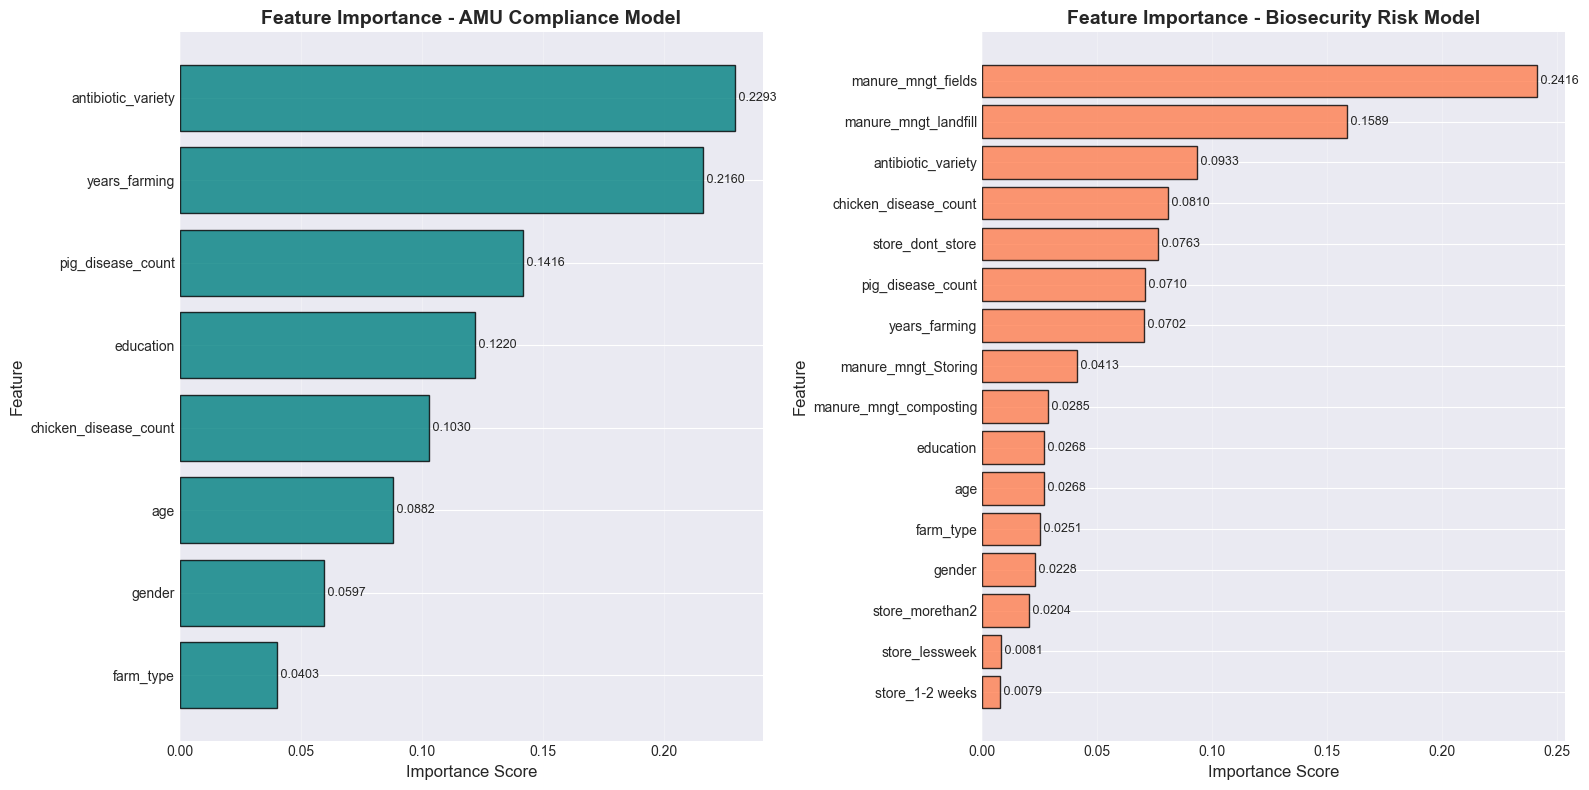


TOP 5 MOST IMPORTANT FEATURES

AMU Compliance Model:
  chicken_disease_count: 0.1030
  education: 0.1220
  pig_disease_count: 0.1416
  years_farming: 0.2160
  antibiotic_variety: 0.2293

Biosecurity Risk Model:
  store_dont_store: 0.0763
  chicken_disease_count: 0.0810
  antibiotic_variety: 0.0933
  manure_mngt_landfill: 0.1589
  manure_mngt_fields: 0.2416


In [102]:
# Detailed feature importance analysis for both models
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# AMU Model Feature Importance
amu_importance = pd.DataFrame({
    'feature': amu_features,
    'importance': amu_model.feature_importances_
}).sort_values('importance', ascending=True)

axes[0].barh(amu_importance['feature'], amu_importance['importance'], 
             color='teal', edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Importance Score', fontsize=12)
axes[0].set_ylabel('Feature', fontsize=12)
axes[0].set_title('Feature Importance - AMU Compliance Model', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

# Add values on bars
for i, (feat, imp) in enumerate(zip(amu_importance['feature'], amu_importance['importance'])):
    axes[0].text(imp, i, f' {imp:.4f}', va='center', fontsize=9)

# Biosecurity Model Feature Importance
bio_importance = pd.DataFrame({
    'feature': bio_features,
    'importance': bio_model.feature_importances_
}).sort_values('importance', ascending=True)

axes[1].barh(bio_importance['feature'], bio_importance['importance'], 
             color='coral', edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Importance Score', fontsize=12)
axes[1].set_ylabel('Feature', fontsize=12)
axes[1].set_title('Feature Importance - Biosecurity Risk Model', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

# Add values on bars
for i, (feat, imp) in enumerate(zip(bio_importance['feature'], bio_importance['importance'])):
    axes[1].text(imp, i, f' {imp:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("TOP 5 MOST IMPORTANT FEATURES")
print("=" * 80)

print("\nAMU Compliance Model:")
for i, row in amu_importance.tail(5).iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")

print("\nBiosecurity Risk Model:")
for i, row in bio_importance.tail(5).iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")

## 16. Conclusion and Next Steps

In [103]:
print("=" * 80)
print("LIVESTOCK MONITORING & BIOSECURITY AI SYSTEM")
print("ANALYSIS COMPLETE")
print("=" * 80)

print("\n📊 ANALYSIS SUMMARY:")
print(f"  • Total farms analyzed: {len(df_processed)}")
print(f"  • High-risk farms identified: {df_processed['high_risk'].sum()}")
print(f"  • Non-compliant farms identified: {df_processed['non_compliant'].sum()}")
print(f"  • Anomalous farms detected: {df_with_anomalies['anomaly'].sum()}")

print("\n🤖 MACHINE LEARNING MODELS:")
print(f"  • AMU Compliance Model Accuracy: {amu_accuracy*100:.2f}%")
print(f"  • Biosecurity Risk Model Accuracy: {bio_accuracy*100:.2f}%")
print(f"  • Models saved and ready for deployment")

print("\n📁 OUTPUTS GENERATED:")
print("  • processed_livestock_data.csv - Full processed dataset")
print("  • livestock_models.pkl - All trained models")
print("  • amu_model.pkl - AMU compliance model")
print("  • bio_model.pkl - Biosecurity risk model")
print("  • high_risk_farms_report.csv - High-risk farms list")
print("  • non_compliant_farms_report.csv - Non-compliant farms list")
print("  • anomalous_farms_report.csv - Anomalous farms list")
print("  • farm_type_summary_statistics.csv - Summary by farm type")

print("\n🎯 NEXT STEPS:")
print("  1. Review high-risk and non-compliant farms for targeted interventions")
print("  2. Conduct field inspections of anomalous farms")
print("  3. Implement recommended training and compliance programs")
print("  4. Monitor model performance with new data")
print("  5. Update models periodically with fresh data")
print("  6. Deploy models in production environment")
print("  7. Establish regular reporting cycles")

print("\n✅ All analysis completed successfully!")
print("=" * 80)

# Display system information

print("\n" + "=" * 80)

LIVESTOCK MONITORING & BIOSECURITY AI SYSTEM
ANALYSIS COMPLETE

📊 ANALYSIS SUMMARY:
  • Total farms analyzed: 118
  • High-risk farms identified: 31
  • Non-compliant farms identified: 30
  • Anomalous farms detected: 12

🤖 MACHINE LEARNING MODELS:
  • AMU Compliance Model Accuracy: 70.83%
  • Biosecurity Risk Model Accuracy: 87.50%
  • Models saved and ready for deployment

📁 OUTPUTS GENERATED:
  • processed_livestock_data.csv - Full processed dataset
  • livestock_models.pkl - All trained models
  • amu_model.pkl - AMU compliance model
  • bio_model.pkl - Biosecurity risk model
  • high_risk_farms_report.csv - High-risk farms list
  • non_compliant_farms_report.csv - Non-compliant farms list
  • anomalous_farms_report.csv - Anomalous farms list
  • farm_type_summary_statistics.csv - Summary by farm type

🎯 NEXT STEPS:
  1. Review high-risk and non-compliant farms for targeted interventions
  2. Conduct field inspections of anomalous farms
  3. Implement recommended training and compl

---

## End of Notebook

**Thank you for using the Livestock Monitoring & Biosecurity AI System!**
